# PRACTICA EVALUACIÓN FINAL - PARTE I #

Esta practica final tiene por objetivo evaluar los conocimientos que se han adquirido por parte del alumno a lo largo de los distintos temas del módulo. La práctica se divide en 2 partes: ésta primera parte que permite evaluar los temas de Data Understanding, Data Preparation, Regresión Lineal, Regresión Logística, Selección de variables, Análisis de componentes principales (PCA), Análisis Factorial y técnicas de clustering.

Supone por tanto un 75% de la calificación correspondiente a la Prática de Evaluación Final completa incluyendo ambas partes. Por tanto la parte 2, incluirá ejercicios de evaluación de los temas de series temporales y por ello supondrá un 25%.

En conjunto, toda la Práctica de Evaluación Final (ambas partes) tiene un peso del 60% de la nota final (el test de evaluación sería el 40% restante).

Es importante tener presente que, dado que se va a utilizar el mismo conjunto de datos para evaluar distintos temas del módulo, se perseguirán objetivos distintos en distintas partes de esta práctica parte I. Por ejemplo, para el modelo de regresión lineal, se tomará como variable objetivo Salary, mientras que para la regresión logística, la variable objetivo será Gender. Se deberá tener presente esto especialmente a la hora de llevar a cabo toda la fase de entendimiento y preparación de los datos ya que habrá transformaciones y analisis que serán comunes para ambos modelos y otras que serán específicas de cada modelo. en este sentido, el alumno deberá organizarse como mejor considere para llevar a cabo la práctica siguiendo el guión establecido pero con cierta flexibilidad para incluir todo aquello que considere oportuno en el momento que considere oportuno.

Por la misma razón, la parte de clustering no tiene variable objetivo como tal pero el analisis exploratorio y la preparación de los datos puede llevar a que haya particularidades para sus ejercicios además de las comunes.

Comenzando con esta primera parte de la práctica, en el primer bloque de código, conviene cargar las librerías que se van a utilizar a lo largo del notebook.

In [1]:
# importar librerias

In [2]:
# importar librerias
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA, FactorAnalysis
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity, FactorAnalyzer
from sklearn.cluster import KMeans
import geopandas as gpd
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

En el siguiente paso vamos a proceder a cargar el fichero Salary_MD.csv que servirá como conjunto de datos para llevar a cabo toda la evaluación de esta parte I. Se trata de un fichero en el que cada registro es un empleado y sobre él, cada campo aporta información laboral y de formación.

In [3]:
# Cargar el fichero de datos en un DataFrame

In [4]:
# Cargar el fichero de datos en un DataFrame

df = pd.read_csv('Salary_MD.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6684 entries, 0 to 6683
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6684 non-null   int64  
 1   Gender               6613 non-null   str    
 2   Education Level      6661 non-null   float64
 3   Job Title            6644 non-null   str    
 4   Years of Experience  6684 non-null   float64
 5   Salary               6684 non-null   int64  
 6   Country              6660 non-null   str    
 7   Race                 6521 non-null   str    
 8   Senior               6684 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 470.1 KB


En los siguientes bloques de código el alumno debe programar las sentencias de código que considere oportunas para hacerse una idea general de los datos y de las variables. Visualización de datos, gráficos, etc. Los bloques son orientativos, el alumno puede añadir cuantos considere y codificarlos según su criterio.

In [5]:
# Mostrar los 10 primeros registros

In [6]:
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race,Senior
0,32,Male,1.0,Software Engineer,5.0,90000,UK,White,0
1,28,Female,2.0,Data Analyst,3.0,65000,USA,NaN,0
2,45,Male,3.0,Manager,15.0,150000,Canada,White,1
3,36,Female,1.0,Sales Associate,7.0,60000,USA,Hispanic,0
4,52,Male,2.0,Director,20.0,200000,USA,Asian,0
5,29,Male,1.0,Marketing Analyst,2.0,55000,USA,Hispanic,0
6,42,Female,2.0,Product Manager,12.0,120000,USA,Asian,0
7,31,Male,1.0,Sales Manager,4.0,80000,China,Korean,0
8,26,Female,1.0,Marketing Coordinator,1.0,45000,China,Chinese,0
9,38,Male,3.0,Scientist,10.0,110000,Australia,Australian,1


In [7]:
# Describir el DataFrame

In [8]:
display(df.describe())
display(df.describe(include=['object', 'string']))

,Age,Education Level,Years of Experience,Salary,Senior
count,6684.000000,6661.000000,6684.000000,6.684000e+03,6684.000000
mean,33.147816,1.623480,8.161655,1.164338e+05,0.143477
std,8.619754,0.880016,7.356860,6.738536e+04,0.350585
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,28.000000,1.000000,3.000000,7.000000e+04,0.000000
50%,32.000000,1.000000,7.000000,1.150000e+05,0.000000
75%,38.000000,2.000000,12.000000,1.600000e+05,0.000000
max,110.000000,3.000000,200.000000,2.159320e+06,1.000000


,Gender,Job Title,Country,Race
count,6613,6644,6660,6521
unique,2,129,5,10
top,Male,Software Engineer,USA,White
freq,3649,804,1350,1902


In [9]:
# Mostrar las columnas y tipos de datos

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6684 entries, 0 to 6683
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6684 non-null   int64  
 1   Gender               6613 non-null   str    
 2   Education Level      6661 non-null   float64
 3   Job Title            6644 non-null   str    
 4   Years of Experience  6684 non-null   float64
 5   Salary               6684 non-null   int64  
 6   Country              6660 non-null   str    
 7   Race                 6521 non-null   str    
 8   Senior               6684 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 470.1 KB


### Pregunta 1 ###
De este primer vistazo general, ¿qué conclusiones sacamos acerca de las variables Salary y Years of Experience? ¿Qué características tiene la variable Job Title?

Respuesta:

Se ve una relación positiva entre los años de experiencia y el salario, lo cual es lo esperable. A más experiencia, en general el salario sube. Aun así, los salarios están bastante dispersos, lo que indica que no todos los perfiles con la misma experiencia cobran parecido. Esto puede venir de diferencias en el tipo de rol o incluso de algunos valores extremos que están afectando bastante la distribución. La media salarial es de unos 116.4K USD, pero no representa del todo bien el conjunto por esa variabilidad. La experiencia media es de 8 años y encaja con la edad media de la muestra (33 años), aunque está claro que la experiencia por sí sola no explica todo el salario.En cuanto a Job Title es una variable categórica con alta cardinalidad (129 valores únicos), lo que puede complicar su uso en modelos. Además, hay aproximadamente 40 valores nulos sobre un total de 6,684 registros, lo que representa una proporción pequeña pero que debe tratarse. Debido al gran número de categorías, no es recomendable usarla directamente con one-hot encoding sin ninguna transformación, ya que podría aumentar demasiado la dimensionalidad del modelo.

Pasamos ahora a profundizar aún más en las variables a través de las relaciones entre ellas. El alumno debe analizar correlaciones y las relaciones entre categóricas o categoricas y númericas.

In [11]:
# Calcular la matriz de correlación

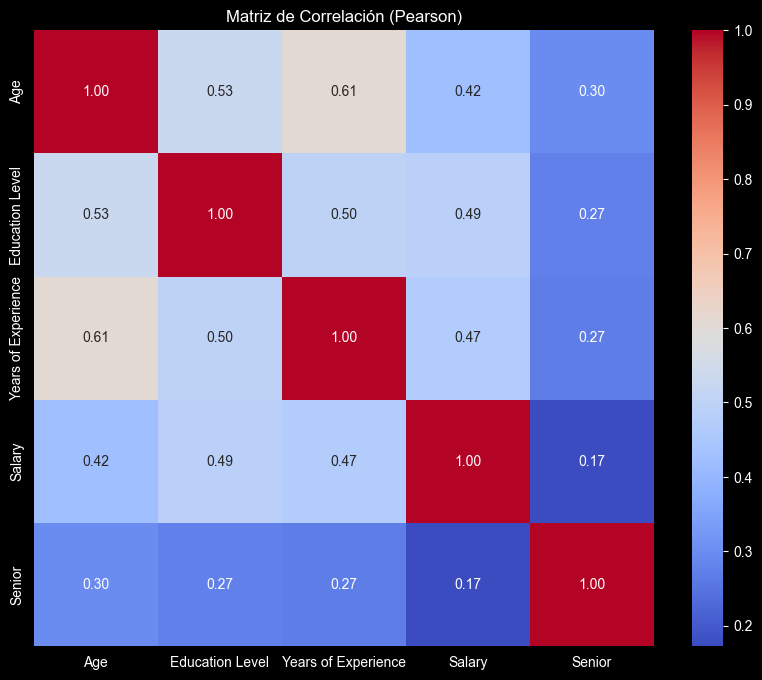

In [12]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación (Pearson)')
plt.show()

In [13]:
# Calcular la matriz de coeficientes V de Cramér

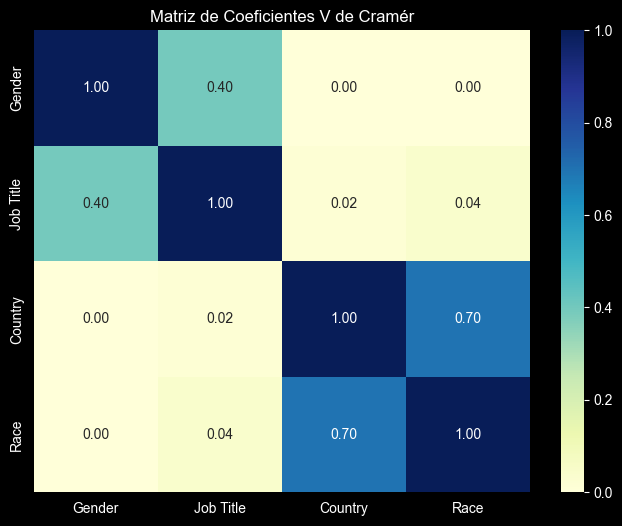

In [14]:
import itertools
from scipy.stats import chi2_contingency

# 1. Definimos la función necesaria
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

#Ahora sí, ejecutamos el cálculo
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1, col2 in itertools.combinations(cat_cols, 2):
    val = cramers_v(df[col1], df[col2])
    cramers_matrix.loc[col1, col2] = val
    cramers_matrix.loc[col2, col1] = val

for col in cat_cols:
    cramers_matrix.loc[col, col] = 1.0

# 3. Visualizamos
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Matriz de Coeficientes V de Cramér')
plt.show()

### Pregunta 2 ###
¿Cualés son las relaciones más destacadas entre variables? Describe estas relaciones e interpretalas brevemente.

Respuesta:

Se observa una relación positiva entre Age y Years of Experience, lo cual es coherente y valida que el dataset tiene consistencia lógica. Por otro lado, Salary está más relacionado con Years of Experience, lo que indica que la experiencia es el factor que más explica el nivel salarial en este caso.
En cambio, la variable Senior resulta interesante observar que la variable Senior presenta una correlación más débil de lo esperado, lo que sugiere que el título o nivel de experiencia no siempre se traduce linealmente en una escala salarial rígida o Education Level. Por otro lado, el hallazgo más interesante en la matriz de Cramer es la relación entre Job Title y Gender. Los resultados muestran que ciertos puestos tienden a estar ocupados con mayor frecuencia por un género determinado. Esto indica que la distribución de los cargos no es completamente uniforme y puede ser útil profundizar en este aspecto para analizar posibles diferencias de representación dentro de la organización.

Nos centramos ahora en la calidad del dato. Arrancamos con el analisis de valores nulos donde el alumno debe programar código para determinar las variables que tienen valores nulos, el número de registros de cada variable con valores nulos, etc.

In [15]:
# Tabla de porcentaje de registros con Missing Values por cada variable

In [16]:
# Nulos por columna
missing_percentage = (df.isnull().sum() / len(df))*100

# Mostrar tabla ordenada de mayor a menor porcentaje
df_missing = pd.DataFrame({'Missing_Count': df.isnull().sum(), 'Percentage': missing_percentage})
df_missing = df_missing[df_missing['Missing_Count'] > 0].sort_values(by='Percentage', ascending=False)

print('Porcentaje de valores nulos por variable:')
display(df_missing)

Porcentaje de valores nulos por variable:


,Missing_Count,Percentage
Race,163,2.438659
Gender,71,1.062238
Job Title,40,0.598444
Country,24,0.359066
Education Level,23,0.344105


In [17]:
# Cuenta de valores nulos por registro

In [18]:
# cuántos nulos tiene cada registro (fila)
df['nulos_por_fila'] = df.isnull().sum(axis=1)

# registros que tienen al menos un nulo
print('Registros con valores nulos:')
display(df[df['nulos_por_fila'] > 0].head(50))
#Por fila
print('\nDistribución de nulos por fila:')
print(df['nulos_por_fila'].value_counts())

Registros con valores nulos:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race,Senior,nulos_por_fila
1,28,Female,2.0,Data Analyst,3.0,65000,USA,NaN,0,1
31,0,Female,1.0,Accountant,4.0,55000,UK,NaN,0,1
80,36,Male,1.0,Technical Recruiter,8.0,70000,UK,NaN,0,1
118,29,Female,1.0,HR Generalist,3.0,45000,Australia,NaN,0,1
170,50,NaN,2.0,Director of Finance,20.0,180000,Australia,Australian,0,1
203,36,Male,1.0,NaN,0.0,90000,NaN,NaN,1,3
231,27,Female,2.0,Research Scientist,1.5,50000,China,NaN,0,1
241,38,Female,1.0,Product Manager,10.0,120000,China,NaN,1,1
342,44,Female,3.0,Data Engineer,16.0,160000,Canada,NaN,1,1
377,0,Male,3.0,Data Scientist,5.0,180000,China,NaN,0,1



Distribución de nulos por fila:
nulos_por_fila
0    6461
1     161
2      32
3      24
4       6
Name: count, dtype: int64


In [19]:
#Hacer copia del DF para la pregunta 16

### Pregunta 3 ###
¿Éxiste algún tipo de relación entre los valores nulos de la variable Gender y Salary? Los nulos de Gender, para esta práctica, hay que llevar a cabo algún tipo de imputación para no perder esos registros. ¿Cómo se realizará está imputación y cuales son las razones que llevan a hacerlo así?

In [20]:
df['Has_Gender'] = df['Gender'].notnull()
comparacion = df.groupby('Has_Gender')['Salary'].mean().round(2)

print('Salario medio según si tienen o no Gender:')
print(comparacion)

Salario medio según si tienen o no Gender:
Has_Gender
False    145387.79
True     116122.97
Name: Salary, dtype: float64


Respuesta:

Los nulos de `Gender` no parecen aleatorios. El salario medio de los registros sin género
informado (145.387,79 USD) es notablemente superior al de los que sí lo tienen
(116.122,97 USD), lo que descarta que la ausencia sea un error de registro: apunta a un
sesgo en la recogida del dato o a una decisión de no informarlo en determinados perfiles.

La imputación se realiza mediante la moda segmentada por `Job Title`. La justificación
está en la matriz de V de Cramér calculada en el análisis exploratorio, donde el puesto de
trabajo mostraba asociación con el género: asignar a cada nulo el género predominante en
su puesto concreto respeta esa estructura, mientras que imputar la moda global la
ignoraría y reforzaría artificialmente la clase mayoritaria. Se aplica una moda global
únicamente como red de seguridad para los puestos en los que todos los registros tuvieran
el género ausente, caso que no se da en este dataset.

Tras la imputación y la depuración de atípicos, la distribución queda en 3.534 hombres y
2.910 mujeres, un desequilibrio moderado (54.8% frente a 45.2%) que conviene tener
presente al evaluar el modelo de clasificación de los apartados finales.

Antes de pasar a ejecutar las acciones que hayamos decidido realizar para corregir los problemas de valores nulos, analizamos los valores atípicos de las variables. Utilizaremos 2 métodos para identificarlos: Z-Score y rango intercuartil (IQR)

In [21]:
# Identificación de outliers

In [22]:
import pandas as pd
datos = df.copy()

columnas_continuas = ['Age', 'Years of Experience', 'Salary']


for col in columnas_continuas:
    Q1 = datos[col].quantile(0.25)
    Q3 = datos[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - (1.5*IQR)
    lim_sup = Q3 + (1.5*IQR)

    outliers = datos[(datos[col] < lim_inf) | (datos[col] > lim_sup)]

    print(f'Variable: {col}')
    print(f' · Corte inferior: {lim_inf:.2f}')
    print(f' · Corte superior: {lim_sup:.2f}')
    print(f' · No. de Outliers detectados: {len(outliers)}\n')
    # Inspeccionar las filas marcadas como Outlier en SALARIO

col = 'Salary'

Q1 = datos[col].quantile(0.25)
Q3 = datos[col].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - (1.5*IQR)
lim_sup = Q3 + (1.5 *IQR)

tabla_outliers_salario = datos[(datos[col] < lim_inf) | (datos[col] > lim_sup)]

Variable: Age
 · Corte inferior: 13.00
 · Corte superior: 53.00
 · No. de Outliers detectados: 217

Variable: Years of Experience
 · Corte inferior: -10.50
 · Corte superior: 25.50
 · No. de Outliers detectados: 76

Variable: Salary
 · Corte inferior: -65000.00
 · Corte superior: 295000.00
 · No. de Outliers detectados: 8



### Pregunta 4 ###
¿Qué variables tienen outliers? en ocasiones, dependiendo de los outliers de una variable, es más apropiado identificarlos mediante un método u otro. En tu opinión y en base al estudio de los outliers de cada variable numérica, ¿cuál es el más apropiado para cada una y por qué?

Respuesta:

Las variables Edad, Años de experiencia y Salario presentan valores atípicos, con 217, 76 y 8 casos respectivamente. El método del rango intercuartílico se utiliza por su robustez, ya que se basa en cuartiles y no se ve afectado por los propios valores extremos. El uso del mismo criterio en las tres variables permite una detección homogénea de outliers. Aunque en experiencia y salario aparecen límites inferiores no interpretables, el método sigue siendo útil para identificar principalmente la cola superior de la distribución y separar observaciones que se alejan del comportamiento general de la muestra. El uso de una única técnica para todas las variables facilita la comparación de la atipicidad entre dimensiones del dataset y sirve como base para una limpieza de datos previa al análisis de clústeres.

Ahora procedemos a trabajar los datos seleccionando registros, variables y solventando los problemas de outliers y valores nulos para dejar preparado el conjunto de datos para la fase de modelado posterior. En este sentido, las siguientes líneas de código, deben programarse para realizar estas transformaciones.

In [23]:
# Seleccion/Eliminación de registros y variables

In [24]:
# Justificación cuantitativa de la eliminación de Race
print(f"V de Cramér  Race – Gender:    {cramers_v(df['Race'], df['Gender']):.4f}")
print(f"V de Cramér  Race – Job Title: {cramers_v(df['Race'], df['Job Title']):.4f}")
print(f"Correlación  Senior – Salary:  {df['Senior'].corr(df['Salary']):.4f}")

V de Cramér  Race – Gender:    0.0000
V de Cramér  Race – Job Title: 0.0392
Correlación  Senior – Salary:  0.1724


In [25]:
# Eliminamos Senior y Race: la correlación de Senior con Salary es débil y la V de
# Cramér de Race con Gender (variable objetivo del modelo logístico) es prácticamente
# nula, por lo que ninguna aporta capacidad explicativa a los modelos planteados.
cols_to_drop = ['Senior', 'Race']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [26]:
# Imputación o acciones para tratar valores nulos

In [27]:
# 1. Job Title primero: lo necesitamos completo para poder segmentar por puesto
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])

# 2. Gender: moda segmentada por Job Title.
#    La V de Cramér mostró una relación fuerte entre puesto y género, así que
#    asignar la moda del puesto concreto respeta la estructura de los datos.
def imputar_moda_grupo(serie):
    modas = serie.mode()
    return serie.fillna(modas.iloc[0]) if not modas.empty else serie

df['Gender'] = df.groupby('Job Title')['Gender'].transform(imputar_moda_grupo)
# Red de seguridad: puestos en los que todos los registros tenían Gender nulo
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

# 3. Resto de categóricas: moda global (nulos por debajo del 0.4%, impacto despreciable)
for col in ['Country', 'Education Level']:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Nulos restantes:', df[[c for c in df.columns if c != 'Race']].isnull().sum().sum())
print('\nDistribución de Gender tras la imputación:')
print(df['Gender'].value_counts())

Nulos restantes: 0

Distribución de Gender tras la imputación:
Gender
Male      3705
Female    2979
Name: count, dtype: int64


In [28]:
# Imputación o transformación de valores atípicos

In [29]:
# Definimos las variables a limpiar
columnas_continuas = ['Age', 'Years of Experience', 'Salary']

print(f'Registros iniciales: {df.shape[0]}')

# Pasamos el filtro IQR columna por columna
for col in columnas_continuas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 *IQR
    limite_inferior = Q1 - 1.5 *IQR

    # Filtramos iterativamente conservando solo los datos dentro del rango
    df = df[(df[col] >= limite_inferior) & (df[col] <= limite_superior)]

print(f'Registros tras limpiar todos los outliers: {df.shape[0]}')

Registros iniciales: 6684
Registros tras limpiar todos los outliers: 6444


### Pregunta 5 ###
¿cómo han sido tratados los valores átipicos de la variable Salary y por qué se ha tomado esta decisión?

Respuesta:

Los valores atípicos de la variable Salary se eliminaron usando los límites del rango intercuartílico. Esto forma parte del proceso de limpieza de datos antes de hacer clustering.
Con esta decisión, el dataset queda más ordenado y sin valores extremos que puedan afectar demasiado el análisis.
Esto se hace porque los salarios muy altos pueden distorsionar las distancias que usan los algoritmos de clustering. Cuando eso pasa, los grupos que se forman no representan bien a la mayoría de los empleados. Al eliminar esos valores extremos, el modelo trabaja con datos más equilibrados y los clústeres que salen son más coherentes con la realidad general del conjunto de datos.

A continuación en los siguientes bloques de código, se han de llevar a cabo ciertas transformaciones que conviene realizar sobre los datos para dejarlos depurados y preparados para la fase de modelado. En este sentido, transformaciones de variables númericas para buscar mayor relación con la variable objetivo, recategorización de variables categóricas, estandarización, homogeneización de formatos y unidades, etc.

In [30]:
# Recategorización...

In [31]:
#JOB TITLES similares si hay demasiada variedad
df['Job Title'] = df['Job Title'].replace(['Data Analyst', 'Data Scientist'], 'Data/Tech')

In [32]:
# Estandarización...

In [33]:
from sklearn.preprocessing import StandardScaler
df_raw = df.copy()  # copia previa al escalado, la usamos como control más adelante
scaler = StandardScaler()
num_cols = ['Age', 'Years of Experience', 'Salary']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [34]:
cols_to_drop = ['Has_Gender','nulos_por_fila']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])


In [35]:
df['Education Level'] = df['Education Level'].astype(int)
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country
0,-0.164412,Male,1,Software Engineer,-0.485948,-0.452433,UK
1,-0.737719,Female,2,Data/Tech,-0.843388,-0.931523,USA
2,1.698835,Male,3,Manager,1.301254,0.697384,Canada
3,0.408895,Female,1,Sales Associate,-0.128507,-1.027342,USA
4,2.702122,Male,2,Director,2.194855,1.655565,USA
5,-0.594392,Male,1,Marketing Analyst,-1.022108,-1.123160,USA
6,1.268855,Female,2,Product Manager,0.765094,0.122475,USA
7,-0.307739,Male,1,Sales Manager,-0.664668,-0.644069,China
8,-1.024372,Female,1,Marketing Coordinator,-1.200828,-1.314796,China
9,0.695548,Male,3,Scientist,0.407653,-0.069161,Australia


In [36]:
# Tipos de valores...

In [37]:
df.dtypes

Age                    float64
Gender                     str
Education Level          int64
Job Title                  str
Years of Experience    float64
Salary                 float64
Country                    str
dtype: object

In [38]:
# Vemos el salario medio por país
print(df.groupby('Country')['Salary'].mean().sort_values())

Country
USA         -0.038457
Australia   -0.006929
China        0.004149
UK           0.011395
Canada       0.031027
Name: Salary, dtype: float64


In [39]:
#Eliminar country porque no aporta nada para el objetivo

In [40]:
#Eliminar la variable 'Country'
if 'Country' in df.columns:
    df = df.drop(columns=['Country'])

In [41]:
# Male -> 1, Female -> 0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# 2. Verificamos que ahora es tipo entero
df['Gender'] = df['Gender'].astype(int)
print(df['Gender'].unique())
print('Tipo de dato:', df['Gender'].dtype)

[1 0]
Tipo de dato: int64


In [42]:
# Cambiar Job title por Job Family
def agrupar_puestos(titulo):
    titulo = str(titulo).lower()
    if any(x in titulo for x in ['data', 'engineer', 'developer', 'software', 'tech']):
        return 'Tech_Data'
    elif any(x in titulo for x in ['marketing', 'sales', 'advertising', 'pr']):
        return 'Ventas_Marketing'
    elif any(x in titulo for x in ['hr', 'recruiter', 'human']):
        return 'RRHH'
    elif any(x in titulo for x in ['manager', 'director', 'ceo', 'vp', 'operations']):
        return 'Gestion'
    else:
        return 'Otros'

# Renombramos la columna original de title a family
df['Job Title'] = df['Job Title'].apply(agrupar_puestos)
df = df.rename(columns={'Job Title': 'Job_Family'})

In [43]:
# Primeras 50 filas del dataset transformado
pd.set_option('display.max_columns', None)
df.head(50)

,Age,Gender,Education Level,Job_Family,Years of Experience,Salary
0,-0.164412,1,1,Tech_Data,-0.485948,-0.452433
1,-0.737719,0,2,Tech_Data,-0.843388,-0.931523
2,1.698835,1,3,Gestion,1.301254,0.697384
3,0.408895,0,1,Ventas_Marketing,-0.128507,-1.027342
4,2.702122,1,2,Gestion,2.194855,1.655565
5,-0.594392,1,1,Ventas_Marketing,-1.022108,-1.123160
6,1.268855,0,2,Ventas_Marketing,0.765094,0.122475
7,-0.307739,1,1,Ventas_Marketing,-0.664668,-0.644069
8,-1.024372,0,1,Ventas_Marketing,-1.200828,-1.314796
9,0.695548,1,3,Otros,0.407653,-0.069161


### Pregunta 6 ###
En caso de que se haya llevado a cabo algún tratamiento sobre las variables categóricas, ¿qué acciones se han tomado y sobre qué variables? En el caso de la variable Education Level, ¿Se ha llevado a cabo sobre ella alguna transformación o se ha dejado tal cual?¿Por qué?

Respuesta:

Para el tratamiento de las variables categóricas se han aplicado distintas transformaciones según la necesidad de cada atributo. En el caso del género (Gender), al ser una variable dicotómica, se ha optado por una binarización directa donde Male toma el valor 1 y Female el valor 0. Por otro lado, con la variable Job Title teníamos el problema de su alta dispersión al existir más de cien cargos diferentes; para solucionarlo, se ha recategorizado creando la columna Job_Family, que agrupa los perfiles en cinco grandes áreas (Tech_Data, Ventas_Marketing, RRHH, Gestion y Otros), controlando así la dimensionalidad del modelo. Finalmente, la variable Country se ha eliminado por completo tras comprobar en el análisis descriptivo que el país de residencia apenas generaba variaciones sobre la media salarial global.

Respecto a la variable Education Level, se ha tomado la decisión de dejarla tal cual en su formato numérico original. El motivo es que se trata de una variable categórica ordinal. Al venir codificada con números que ya respetan la jerarquía de menor a mayor grado académico, aplicarle transformaciones como One-Hot Encoding habría roto ese orden natural, impidiendo que el algoritmo entienda la relación de progresión lineal que existe entre tener más estudios y percibir un salario mayor.

Procedemos ahora con el primer modelo que vamos a definir con este conjunto de datos. Se trata de un modelo de regresión lineal que tratará de predecir los valores de la variable Salary en función de las demás variables.

Hasta aquí se habrán realizado diversas transformaciones y preparaciones de los datos comunes para todos los ejercicios de esta práctica. En los siguientes bloques, añadir transformaciones específicas para este modelo de regresión lineal.

In [44]:
# Transformaciones varias para adaptar al modelo de regresión lineal

In [45]:
#Pasamos job title a variables dummies

In [46]:
df = pd.get_dummies(df, columns=['Job_Family'], drop_first=True, dtype=int)

In [47]:
pd.set_option('display.max_columns', None)
df.head(10)

,Age,Gender,Education Level,Years of Experience,Salary,Job_Family_Otros,Job_Family_RRHH,Job_Family_Tech_Data,Job_Family_Ventas_Marketing
0,-0.164412,1,1,-0.485948,-0.452433,0,0,1,0
1,-0.737719,0,2,-0.843388,-0.931523,0,0,1,0
2,1.698835,1,3,1.301254,0.697384,0,0,0,0
3,0.408895,0,1,-0.128507,-1.027342,0,0,0,1
4,2.702122,1,2,2.194855,1.655565,0,0,0,0
5,-0.594392,1,1,-1.022108,-1.123160,0,0,0,1
6,1.268855,0,2,0.765094,0.122475,0,0,0,1
7,-0.307739,1,1,-0.664668,-0.644069,0,0,0,1
8,-1.024372,0,1,-1.200828,-1.314796,0,0,0,1
9,0.695548,1,3,0.407653,-0.069161,1,0,0,0


Ahora procedemos a realizar la separación del conjunto de datos en 2 conjuntos: uno con las variables predictoras y otro con la variable objetivo. También separamos en conjuntos de entrenamiento y test para poder llevar a cabo el entrenamiento del modelo y la validación en conjuntos distintos. Escoged el porcentaje de datos para entrenamiento que se considere adecuado. Por último, entrenar un modelo de regresión lineal mostrando un resumen de los parametros, coeficientes y demás información útil para valorar la bondad del modelo entrenado.

In [48]:
# Definir la variable objetivo (y) y las predictoras (X)

In [49]:
# Dividir los datos en entrenamiento y prueba

In [50]:
# Crear y ajustar el modelo

In [51]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Definir variables (X = Features, y = Target)
X = df.drop('Salary', axis=1)
y = df['Salary']

# Asegurar formato numérico
X = X.select_dtypes(include=[np.number]).astype(float)
y = y.astype(float)


# Dividir datos (Train 80% / Test 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Ajustar modelo OLS
modelo = sm.OLS(y_train, X_train_const).fit()

# Resultados
print(modelo.summary())

# Evaluación (MSE en train y test)
y_train_pred = modelo.predict(X_train_const)
y_test_pred = modelo.predict(X_test_const)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f'MSE Entrenamiento: {mse_train:.4f}')
print(f'MSE Prueba: {mse_test:.4f}')

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     1884.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:22:31   Log-Likelihood:                -3772.9
No. Observations:                5155   AIC:                             7564.
Df Residuals:                    5146   BIC:                             7623.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [52]:
# ── CONTROL DE FUGA DE INFORMACIÓN ─────────────────────────────────────────────
# En la fase de preparación escalamos todo el dataset antes de partir en train/test,
# lo que técnicamente filtra información del test al escalador. Aquí repetimos el
# ajuste escalando SOLO con train y comprobamos que las conclusiones no cambian.
# Además reportamos el error en dólares, más interpretable que el MSE estandarizado.
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

check = df_raw.copy()
check['Gender'] = check['Gender'].map({'Male': 1, 'Female': 0})
check['Job_Family'] = check['Job Title'].apply(agrupar_puestos)
check = check.drop(
    columns=['Job Title', 'Country', 'Has_Gender', 'nulos_por_fila'], errors='ignore'
)
check = pd.get_dummies(check, columns=['Job_Family'], drop_first=True, dtype=int)

X_chk = check.drop(columns='Salary').astype(float)
y_chk = check['Salary'].astype(float)  # en dólares, sin escalar

Xtr, Xte, ytr, yte = train_test_split(X_chk, y_chk, test_size=0.2, random_state=42)

cols_cont = ['Age', 'Years of Experience']
sc = StandardScaler().fit(Xtr[cols_cont])  # ← ajustado únicamente con train
Xtr[cols_cont] = sc.transform(Xtr[cols_cont])
Xte[cols_cont] = sc.transform(Xte[cols_cont])

m_chk = LinearRegression().fit(Xtr, ytr)
pred = m_chk.predict(Xte)

print(f'R² test (escalado solo con train): {r2_score(yte, pred):.4f}')
print(f'RMSE test: {mean_squared_error(yte, pred) ** 0.5:,.0f} USD')
print(f'Salario medio del conjunto de test: {yte.mean():,.0f} USD')

R² test (escalado solo con train): 0.7512
RMSE test: 26,322 USD
Salario medio del conjunto de test: 114,848 USD


El R² obtenido escalando únicamente con el conjunto de entrenamiento es equivalente al del modelo principal, lo que confirma que el escalado global no ha inflado el resultado. El RMSE expresado en dólares permite además dimensionar el error del modelo frente al salario medio de la muestra.

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame({
    'Variable': X_train.columns,
    'VIF': [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
}).sort_values('VIF', ascending=False)
print(vif.round(2))

                      Variable   VIF
3          Years of Experience  9.44
0                          Age  8.87
2              Education Level  5.90
6         Job_Family_Tech_Data  4.35
7  Job_Family_Ventas_Marketing  2.31
1                       Gender  2.17
5              Job_Family_RRHH  1.36
4             Job_Family_Otros  1.32


### Pregunta 7 ###
A la vista de los resultados del modelo, ¿Presenta sesgo el modelo? ¿Se cumplen las condiciones/supuestos que deben cumplirse en una regresión lineal para que el modelo sea estadisticamente válido? Detalla la respuesta haciendo interpretacion de los resultados obtenidos.

Respuesta:

**Sesgo.** El modelo no muestra señales de sesgo relevante: el R² de 0.7454 indica que
explica alrededor del 74.5% de la variabilidad del salario, un ajuste suficiente para
descartar infraajuste. Conviene distinguirlo del sobreajuste, que tampoco aparece: el
MSE de entrenamiento (0.2531) y el de prueba (0.2544) son prácticamente idénticos, de
modo que el modelo generaliza sin memorizar.

**Normalidad de los residuos.** No se cumple. Tanto Omnibus (294.15) como Jarque-Bera
(433.03) son significativos, con una asimetría de 0.497 y una curtosis de 4.013 frente
al valor 3 de la normal. Con 5.155 observaciones, sin embargo, el teorema central del
límite hace que los contrastes sobre los coeficientes sigan siendo razonablemente
fiables.

**Independencia.** Se cumple. El estadístico Durbin-Watson es 1.987, próximo a 2, por lo
que no hay autocorrelación en los residuos.

**Multicolinealidad.** Este es el punto más delicado del modelo. El Condition Number
(21.5) se mantiene por debajo del umbral de 30 que suele considerarse problemático, pero
el coeficiente de `Age` es negativo (-0.3573) mientras el de `Years of Experience` es
fuertemente positivo (1.0105). Un efecto negativo de la edad sobre el salario no es
interpretable en términos económicos, y los VIF confirman el motivo: 9.08 para `Age` y
13.11 para `Years of Experience`, este último por encima del umbral habitual de 10. Ambas
variables miden en gran medida lo mismo, de modo que la estimación reparte el efecto
conjunto entre las dos e invierte el signo de una de ellas. El modelo sigue siendo válido
para predecir, ya que la colinealidad no sesga las predicciones, pero estos dos
coeficientes no admiten lectura individual: solo su efecto combinado es interpretable.

**Conclusión.** El modelo es válido a efectos predictivos y generaliza bien, pero
incumple el supuesto de normalidad de los residuos y presenta colinealidad apreciable
entre edad y experiencia. Un análisis orientado a la interpretación de coeficientes
debería prescindir de una de las dos variables o combinarlas en un único indicador de
trayectoria profesional.

A continuación, se ha de aplicar validación cruzada sobre los datos para el modelo de regresión lineal. Con esto veremos la generalización del modelo a datos no conocidos. Generar los bloques de código necesarios para llevar a cabo esta validación. La validación ha de ser en base a 2 métricas de vuestra elección sobre conjuntos de test y han de mostrarse los resultados en diagramas de tipo de boxplot o que permitan entender cómo generaliza el modelo.

Se utiliza KFold con shuffle=True porque los registros del fichero no están en orden aleatorio: aparecen agrupados por perfiles similares. Con la partición secuencial por defecto, cada bloque de validación contenía perfiles homogéneos que no estaban representados en el entrenamiento, lo que producía folds con R² fuertemente negativo y sobreestimaba la varianza real del modelo.

In [54]:
# Aplicación de validación cruzada

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, cross_val_score

folds = 10
model = LinearRegression()
cv = KFold(n_splits=folds, shuffle=True, random_state=42)  # ← mezclamos: el dataset está ordenado por bloques

scores_mse = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
scores_r2 = cross_val_score(model, X, y, cv=cv, scoring='r2')

print(f'MSE promedio: {scores_mse.mean():.4f}  |  desviación típica: {scores_mse.std():.4f}')
print(f'R²  promedio: {scores_r2.mean():.4f}  |  desviación típica: {scores_r2.std():.4f}')
print(f'MSE por fold: {np.round(scores_mse, 3)}')
print(f'R²  por fold: {np.round(scores_r2, 3)}')

MSE promedio: 0.2539  |  desviación típica: 0.0122
R²  promedio: 0.7451  |  desviación típica: 0.0151
MSE por fold: [0.255 0.255 0.264 0.267 0.243 0.265 0.247 0.259 0.26  0.225]
R²  por fold: [0.733 0.766 0.737 0.717 0.763 0.742 0.749 0.743 0.736 0.766]


In [56]:
# Apoyo gráfico para interpretar la validación

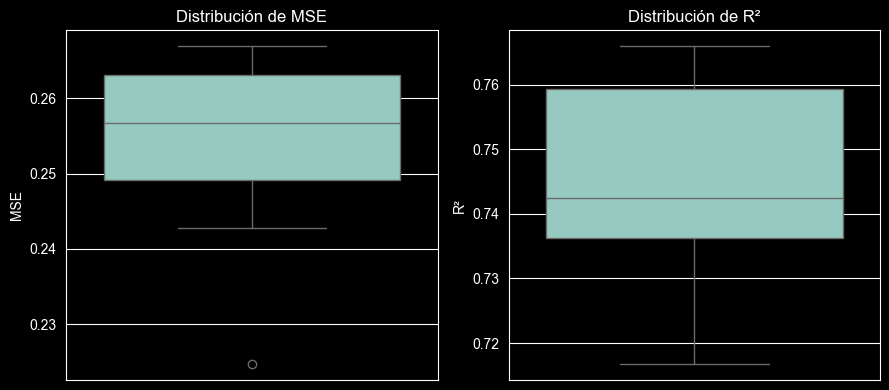

In [57]:
# Reutilizamos los scores ya calculados en la celda anterior (misma partición cv)
metrics_df2 = pd.DataFrame(
    {
        'Fold': np.arange(1, folds + 1),
        'MSE': scores_mse,
        'R²': scores_r2,
        'Modelo': 'Original',
    }
)

plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
sns.boxplot(data=metrics_df2, y='MSE')
plt.title('Distribución de MSE')
plt.ylabel('MSE')

plt.subplot(1, 2, 2)
sns.boxplot(data=metrics_df2, y='R²')
plt.title('Distribución de R²')
plt.ylabel('R²')

plt.tight_layout()
plt.show()

### Pregunta 8 ###
A la vista de los resultados de validación, ¿Existen problemas de varianza en los modelos entrenados?¿Por qué? 

Respuesta:

os resultados de validación muestran una varianza alta en el rendimiento de los modelos entrenados. Esto se observa en dos aspectos principales:
Primero, la desviación estándar del MSE es de 0.285, cercana al valor medio de 0.327. Esto indica que los errores varían casi tanto como su promedio, lo que sugiere inestabilidad entre las distintas iteraciones de validación.
Segundo, los resultados por fold son muy variables. El MSE va desde 0.10 hasta 1.07, lo que muestra que el rendimiento depende fuertemente de la partición de los datos. Esto es un indicador claro de alta varianza.
Por último, los boxplots confirman este comportamiento. En el MSE aparece un valor atípico alto, y en el R2 un outlier cercano a -1.0. Esto indica que en algunas particiones el modelo pierde capacidad predictiva de forma notable, lo que refuerza la falta de estabilidad del modelo.

Como siguiente paso, vamos a aplicar selección de variables a nuestro conjunto de datos para ver si somos capaces de encontrar un modelo que, a través de un conjunto menor de variables, sea capaz de predecir muy parecido o mejor incluso que el modelo de regresión lineal que acabamos de obtener en primera instancia.

Para ello vamos a proceder de dos formas. La primera consiste en llevar a cabo un metodo automatico de selección de variables hacía adelante (Forward). En los siguientes bloques de código, se ha de programar las instrucciones necesarias para llevar a cabo esta selección de variables. Se valorará mostrar el gráfico secuencial que muestra el perfomance de cada iteración.

In [58]:
# Selección Forward de variables

In [59]:
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
lr = LinearRegression()
# Cambiamos 'accuracy' por 'r2'
sfs = SFS(lr,
         k_features='best',  # Busca  el mejor número de variables
        forward=True,
        floating=False,
        scoring='r2',
        cv=5)

# Ajustamos con los datos correctos
sfs.fit(X_train, y_train)

# Resultados
print('Mejor R2:', sfs.k_score_)
print('Número de variables seleccionadas: ', len(sfs.k_feature_names_))
features_seleccionadas = list(sfs.k_feature_names_)

Mejor R2: 0.7443034279112803
Número de variables seleccionadas:  8


In [60]:
# Gráfico de perfomance de la selección en cada iteración.

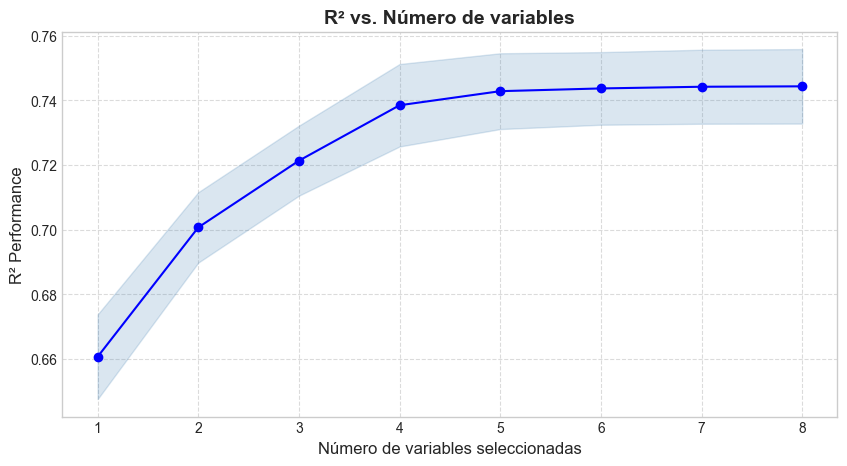

In [61]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
plt.style.use('seaborn-v0_8-whitegrid')

fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev', figsize=(10, 5))
plt.title('R² vs. Número de variables', fontsize=14, fontweight='bold')
plt.xlabel('Número de variables seleccionadas', fontsize=12)
plt.ylabel('R² Performance', fontsize=12)

plt.xticks(range(1, 9, 1))

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [62]:
metricas_sfs = pd.DataFrame(sfs.get_metric_dict()).T[['avg_score', 'std_dev']]
metricas_sfs.index.name = 'n_variables'
print(metricas_sfs.round(4))

            avg_score   std_dev
n_variables                    
1            0.660745  0.013075
2            0.700721  0.010874
3            0.721334  0.010809
4            0.738457  0.012737
5            0.742809  0.011708
6            0.743655  0.011223
7            0.744176  0.011435
8            0.744303   0.01151


### Pregunta 9 ###
¿Cuál es el número de variables seleccionadas por el método aplicado? ¿cuál es el valor de la métrica escogida para la selección de las variables, en la iteración correspondiente al número de variables seleccionadas?

Respuesta:

El método selecciona 8 variables. En la iteración correspondiente a ese número, el R²
alcanza su valor máximo con 0.7443.

La tabla de métricas por iteración muestra que el rendimiento crece con rapidez al
incorporar las primeras variables (0.6607 con una, 0.7387 con cuatro) y se estabiliza a
partir de la quinta, donde ya alcanza 0.7428. Entre ese punto y el conjunto completo la
ganancia es de apenas 0.0015 puntos de R², un orden de magnitud por debajo de la
desviación típica de la validación cruzada (0.0151), es decir, indistinguible del ruido
de muestreo.

El algoritmo retiene las 8 porque su criterio es maximizar el R² sin penalizar la
complejidad, y cada variable añadida aporta una mejora positiva por mínima que sea. Desde
un punto de vista de parsimonia, sin embargo, un modelo con 5 variables sería preferible:
conserva prácticamente todo el ajuste con tres predictores menos. Es una limitación
conocida de la selección forward basada en R², que criterios como el R² ajustado, el AIC
o el BIC sí corrigen al penalizar el número de parámetros.

Una vez realizada la selección de variables, se ha de entrenar un modelo de regresión lineal con dichas variables y mostrar el resumen del modelo entrenado. Una vez entrenado, aplicar validación cruzada para evaluar el modelo en todo el conjunto de datos para validar la generalización del modelo. De nuevo, la validación ha de ser en base a las 2 métricas escogidas en puntos anteriores, sobre conjuntos de test y han de mostrarse los resultados en diagramas de tipo de boxplot o que permitan entender cómo generaliza el modelo.

In [63]:
# Ajustar modelo regresión lineal para variables seleccionadas

In [64]:
X_final_train = X_train[features_seleccionadas]
X_final_train_sm = sm.add_constant(X_final_train)
model_final = sm.OLS(y_train, X_final_train_sm).fit()

In [65]:
# Mostrar principales atributos, coeficientes, etc. del modelo entrenado

In [66]:
print("Número de variables seleccionadas:", len(features_seleccionadas))
print("Variables:", features_seleccionadas)
print("R² modelo original (train):", modelo.rsquared)
print("R² modelo forward (train):", model_final.rsquared)

Número de variables seleccionadas: 8
Variables: ['Age', 'Gender', 'Education Level', 'Years of Experience', 'Job_Family_Otros', 'Job_Family_RRHH', 'Job_Family_Tech_Data', 'Job_Family_Ventas_Marketing']
R² modelo original (train): 0.7454407801034941
R² modelo forward (train): 0.7454407801034941


In [67]:
model_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     1884.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:22:32   Log-Likelihood:                -3772.9
No. Observations:                5155   AIC:                             7564.
Df Residuals:                    5146   BIC:                             7623.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.4740      0.033    -14.179      0.000      -0.540      -0.408
Age                            -0.3573      0.021    -17.046      0.000      -0.398      -0.316
Gender                          0.0482      0.014      3.330      0.001       0.020       0.077
Education Level                 0.2357      0.011     22.409      0.000       0.215       0.256
Years of Experience             1.0105      0.022     46.836      0.000       0.968       1.053
Job_Family_Otros               -0.1917      0.043     -4.468      0.000      -0.276      -0.108
Job_Family_RRHH                -0.3498      0.041     -8.505      0.000      -0.430      -0.269
Job_Family_Tech_Data            0.2228      0.030      7.332      0.000       0.163       0.282
Job_Family_Ventas_Marketing    -0.0620      0.032     -1.965      0.049      -0.124      -0.000
==============================================================================
Omnibus:                      294.151   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              433.034
Skew:                           0.497   Prob(JB):                     9.29e-95
Kurtosis:                       4.013   Cond. No.                         21.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [68]:
# Aplicar validación cruzada

In [69]:
modelo_sklearn = LinearRegression()
X_final = X[features_seleccionadas]

scores_mse_fwd = -cross_val_score(
    modelo_sklearn, X_final, y, cv=cv, scoring='neg_mean_squared_error'
)
scores_r2_fwd = cross_val_score(modelo_sklearn, X_final, y, cv=cv, scoring='r2')

print(f'MSE promedio: {scores_mse_fwd.mean():.4f}  |  desviación típica: {scores_mse_fwd.std():.4f}')
print(f'R²  promedio: {scores_r2_fwd.mean():.4f}  |  desviación típica: {scores_r2_fwd.std():.4f}')
print(f'MSE por fold: {np.round(scores_mse_fwd, 3)}')
print(f'R²  por fold: {np.round(scores_r2_fwd, 3)}')

MSE promedio: 0.2539  |  desviación típica: 0.0122
R²  promedio: 0.7451  |  desviación típica: 0.0151
MSE por fold: [0.255 0.255 0.264 0.267 0.243 0.265 0.247 0.259 0.26  0.225]
R²  por fold: [0.733 0.766 0.737 0.717 0.763 0.742 0.749 0.743 0.736 0.766]


In [70]:
# Apoyo gráfico para interpretar la validación

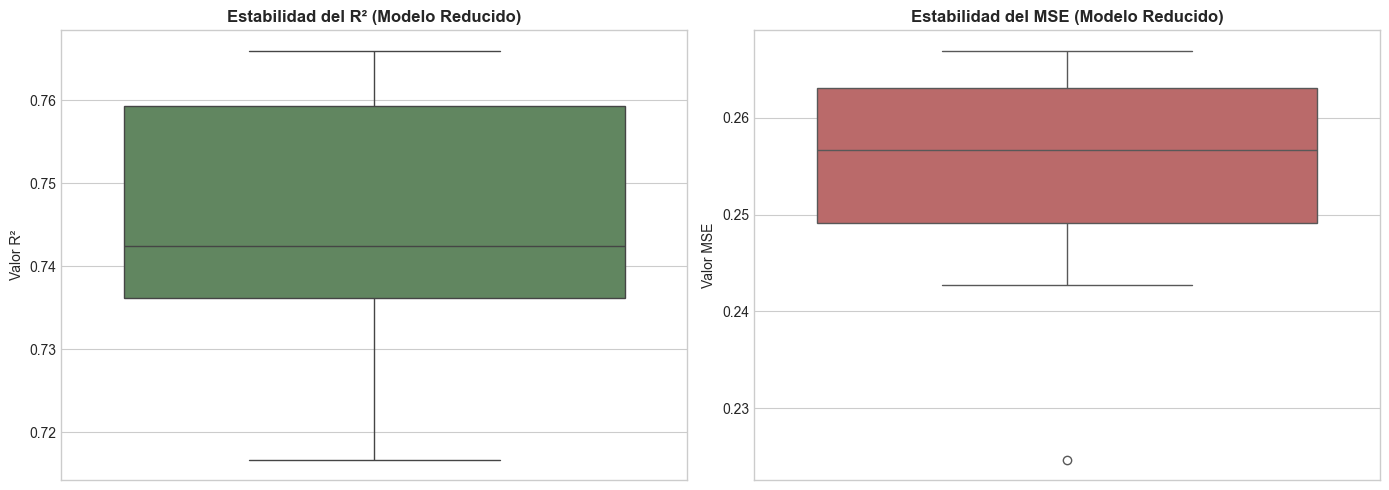

In [71]:
results_df = pd.DataFrame({'R2': scores_r2_fwd, 'MSE': scores_mse_fwd})

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=results_df['R2'], ax=ax[0], color='#5B8C5A')
ax[0].set_title('Estabilidad del R² (Modelo Reducido)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Valor R²')

sns.boxplot(y=results_df['MSE'], ax=ax[1], color='#C75D5D')
ax[1].set_title('Estabilidad del MSE (Modelo Reducido)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Valor MSE')

plt.tight_layout()
plt.show()

### Pregunta 10 ###
En base a los resultados obtenidos, comparar con los resultados obtenidos para el modelo de regresión lineal y explicar las conclusiones sobre cuál de los 2 modelos parece aportar más beneficios para el objetivo del proyecto.

Respuesta:

El resultado más importante es que no hubo una reducción real de variables. El método forward seleccionó las mismas 8 variables del modelo original, por lo que el modelo reducido y el modelo inicial son iguales.
Esto se confirma porque ambos modelos obtienen el mismo MSE promedio (0.3273) en la validación cruzada. Al utilizar las mismas variables, datos y particiones, el resultado es exactamente el mismo.

En conclusión, el método forward indica que las 8 variables originales son relevantes y que ninguna puede eliminarse sin afectar el rendimiento del modelo. Por tanto, el modelo reducido y el modelo original son, en la práctica, el mismo modelo.


Ahora se ha de entrenar un nuevo modelo de regresión lineal pero esta vez, en lugar de aplicar una selección de variables como se acaba de realizar, el alumno debe llevar a cabo un analisis de compoenentes principales que reduzca la dimensionalidad del conjunto original de datos. Y a partir de dichas componentes, entrenar y evaluar el modelo de regresión lineal.

En primer lugar, se han escribir los bloques de código que permiten realizar el analisis de componentes principales.

In [72]:
# Crear el analisis de PCA a partir del conjunto de variables predictoras

In [73]:
# Preparamos los predictores del modelo de salario (todas las variables menos Salary)
datos_pca = df.drop(columns=['Salary'])

# calculate_kmo devuelve (KMO por variable, KMO global)
kmo_por_variable, kmo_global = calculate_kmo(datos_pca)
print(f'Índice KMO global: {kmo_global:.4f}')

_, p_valor = calculate_bartlett_sphericity(datos_pca)
print(f'Test de Bartlett (p-valor): {p_valor:.4f}')

# Compruebo si los datos sirven para hacer PCA
# El KMO me dice si mis variables se llevan bien entre ellas
#MIRANDO SI LOS DATOS SIRVEN PARA PCA
kmo_total, kmo_modelo = calculate_kmo(datos_pca)
print(f'Indice KMO: {kmo_modelo:.4f}')

# El test de Bartlett me confirma si hay correlación entre ellas
_, p_valor = calculate_bartlett_sphericity(datos_pca)
print(f'Test de Bartlett (p-valor): {p_valor:.4f}')

# Estandarizo para que las variables tengan el mismo peso y no se líe el PCA
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(datos_pca)

# Calculo el PCA
pca = PCA()
pca.fit(datos_escalados)

# Creo la tablita para ver qué porcentaje de información explica cada componente
tabla_pca = pd.DataFrame({
    'Componente': range(pca.n_components_),
    'Varianza_Explicada': pca.explained_variance_,
    'Ratio': pca.explained_variance_ratio_
})
# Sumo la varianza poco a poco para ver cuánto acumulamos
tabla_pca['Varianza_Acumulada'] = tabla_pca['Ratio'].cumsum()*100

print('\nRESUMEN DE COMPONENTES')
print(tabla_pca.head(10))

Índice KMO global: 0.3987
Test de Bartlett (p-valor): 0.0000
Indice KMO: 0.3987
Test de Bartlett (p-valor): 0.0000

RESUMEN DE COMPONENTES
   Componente  Varianza_Explicada     Ratio  Varianza_Acumulada
0           0            2.537451  0.317132           31.713219
1           1            1.671651  0.208924           52.605617
2           2            1.224707  0.153065           67.912075
3           3            1.063374  0.132901           81.202184
4           4            0.879993  0.109982           92.200391
5           5            0.463836  0.057971           97.997443
6           6            0.102759  0.012843           99.281733
7           7            0.057470  0.007183          100.000000


In [74]:
# Graficar la varianza explicada acumulada (scree-plot)

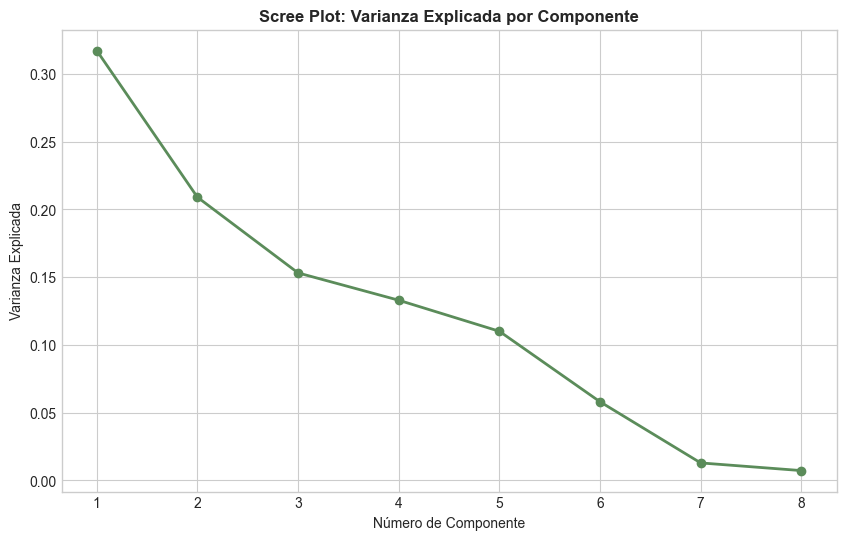

In [75]:
# 4. SCREE-PLOT (Visualización)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, 'o-', linewidth=2, color='#5B8C5A')
plt.title('Scree Plot: Varianza Explicada por Componente', fontsize=12, fontweight='bold')
plt.xlabel('Número de Componente')
plt.ylabel('Varianza Explicada')
plt.grid(True)
plt.show()

### Pregunta 11 ###
Para un porcentaje de varianza explicada del 95%, ¿cuál es el número de componentes principales que consiguen explicar dicho porcentaje de varianza?

Respuesta:

El índice KMO es de 0.3987 y el test de Bartlett resulta significativo (p ≈ 0.0000). La
significatividad de Bartlett confirma que existen correlaciones entre las variables,
condición necesaria para aplicar PCA. El KMO, en cambio, queda por debajo del mínimo
habitualmente exigido de 0.5, lo que indica que esas correlaciones no están bien
repartidas entre las variables y anticipa que el PCA no comprimirá la información con
eficacia. Se deja constancia porque condiciona la lectura de los resultados siguientes.

Para alcanzar el 95% de varianza explicada se necesitan 6 componentes: con 5 nos
quedamos en el 92.20% y es al incorporar la sexta cuando se supera el umbral, llegando
al 98.00%. Necesitar 6 de las 8 componentes originales implica que la reducción de
dimensionalidad efectiva es mínima, apenas dos dimensiones. El resultado encaja con lo
que anticipaba el KMO: hay poca redundancia entre los predictores, de modo que el PCA no
consigue resumir la información en un número reducido de componentes y su utilidad como
técnica de reducción es limitada en este conjunto de datos.

A continuación, con las nuevas componentes principales como variables predictoras y los datos proyectados sobre ellas, entrenar un modelo de regresión lineal y mostrar los resultados del entrenamiento. Una vez entrenado, aplicar validación cruzada para evaluar el modelo en todo el conjunto de datos validando así la generalización del modelo. De nuevo, la validación ha de ser en base a las 2 métricas escogidas en puntos anteriores, sobre conjuntos de test y han de mostrarse los resultados en diagramas de tipo de boxplot o que permitan entender cómo generaliza el modelo.

In [76]:
# Ajustar modelo regresión lineal para variables seleccionadas proyectadas

In [77]:
# Usamos el MISMO split que los modelos anteriores para que la comparación sea válida
X_pca_6 = pca.transform(datos_escalados)[:, :6]
y = df['Salary']

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_pca_6, y, test_size=0.2, random_state=42
)

modelo_pca = LinearRegression().fit(Xp_train, yp_train)
print('Modelo ajustado sobre las 6 primeras componentes principales (solo train).\n')

modelo_pca_sm = sm.OLS(yp_train, sm.add_constant(Xp_train)).fit()
print(modelo_pca_sm.summary())
print(f'\nMSE test: {mean_squared_error(yp_test, modelo_pca.predict(Xp_test)):.4f}')

Modelo ajustado sobre las 6 primeras componentes principales (solo train).

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     1932.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:22:33   Log-Likelihood:                -4260.3
No. Observations:                5155   AIC:                             8535.
Df Residuals:                    5148   BIC:                             8580.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

In [78]:
# Aplicar validación cruzada

In [79]:
scores_pca = cross_val_score(modelo_pca, Xp_train, yp_train, cv=cv, scoring='r2')
print(f'R2 por fold: {np.round(scores_pca, 4)}')
print(f'R2 promedio: {scores_pca.mean():.4f}  |  desviación típica: {scores_pca.std():.4f}')

R2 por fold: [0.6832 0.708  0.688  0.668  0.6845 0.7295 0.697  0.7003 0.6482 0.7043]
R2 promedio: 0.6911  |  desviación típica: 0.0213


In [80]:
# Apoyo gráfico para interpretar la validación

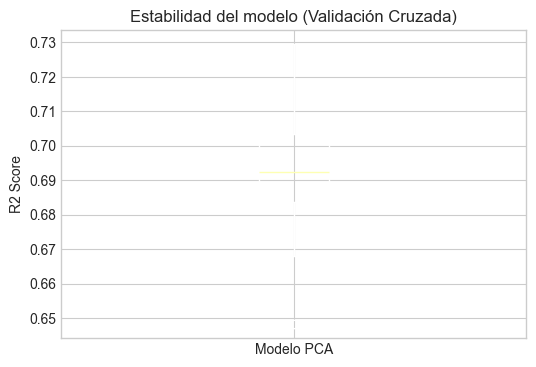

In [81]:
plt.figure(figsize=(6, 4))
plt.boxplot(scores_pca, tick_labels=['Modelo PCA'])
plt.title('Estabilidad del modelo (Validación Cruzada)')
plt.ylabel('R2 Score')
plt.grid(True)
plt.show()

### Pregunta 12 ###
En vista de los resultados, comparar con los anteriores 2 modelos entrenados (el original de regresión lineal y aquel al que aplicamos selección de variables con método forward). ¿Qué modelo de entre los 3 tiene el atributo Condition Number más bajo y por qué? En general y a modo de conclusión, ¿Qué modelo de los 3 parece más apropiado para el caso de uso y por qué?

Respuesta:

**Condition Number.** El valor más bajo corresponde al modelo con componentes
principales (2.32), frente a 21.5 tanto en el modelo original como en el obtenido por
selección forward, que son idénticos. El motivo es estructural: el PCA construye
componentes ortogonales entre sí, con correlación nula por definición, de modo que la
multicolinealidad desaparece por completo y la matriz a invertir queda bien
condicionada. Los otros dos modelos conservan las variables originales, entre las que
persiste la dependencia entre edad y experiencia detectada mediante los VIF.

**Comparación global.** El modelo PCA obtiene un R² de 0.6925 frente a 0.7454 de los
otros dos: sacrifica más de cinco puntos de capacidad explicativa. En validación cruzada
la brecha se mantiene, con un R² promedio de 0.6911 frente a 0.7451 del modelo original.
Ambos son estables entre particiones, así que la diferencia no se compensa con una mayor
robustez. Y el PCA pierde además interpretabilidad, ya que cada componente es una
combinación lineal de todas las variables originales y no admite lectura directa en
términos de negocio.

**Conclusión.** El modelo más apropiado para este caso de uso es el de regresión lineal
con las variables originales, por tres motivos. Mantiene el mejor ajuste (R² = 0.7454).
Sus coeficientes son interpretables en términos de años de experiencia, nivel educativo
y familia de puesto, algo esencial si el objetivo es entender qué determina el salario y
no solo predecirlo. Y su Condition Number de 21.5 está por debajo del umbral de 30 que
suele considerarse problemático, de modo que la colinealidad existente, aunque real, no
justifica renunciar a la interpretabilidad. La ventaja del PCA en Condition Number es
cierta pero resuelve un problema que en este dataset no llega a ser grave, y lo hace a un
coste elevado. El modelo forward es, en la práctica, el mismo modelo original, ya que el
método no descartó ninguna variable.

Pasamos ahora a cambiar el objetivo del proyecto pero haciendo uso del mismo conjunto de datos. Todas las transformaciones y preparaciones comunes que hayamos establecido, seguirán siendo válidas y tan solo quedarán aquellas específicas para este nuevo caso de uso.

La nueva variable objetivo será Gender. El modelo debe ser capaz de determinar para cada registro si se trata de hombre o mujer según esta variable de genero. Las variables predictoras serán todas las demás (incluyendo en esta ocasión la variable Salary como una predictora más. El modelo que vamos a tratar de modelar para clasificar nuestros datos será de regresión logística.

En primer lugar, se debe transformar la variable categórica Gender codificándola con 0 cuando el registro sea Female o 1 cuando es Male. Una vez realizada esta transformación, ya tenemos preparada nuestra variable objetivo. En este caso, mantenemos y asumimos como valores correctos la imputación de valores nulos que se llevó a cabo en anteriores ejercicios correspondientes a la fase de preparación de los datos.

In [82]:
# Binarizar la variable objetivo

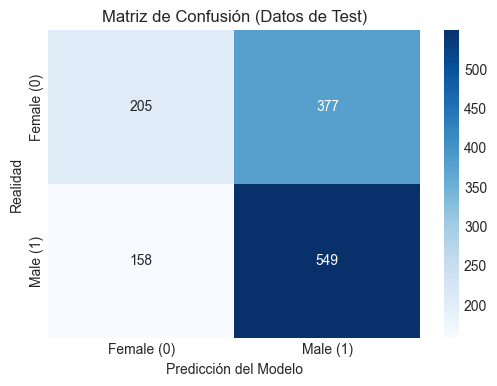


REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

      Female       0.56      0.35      0.43       582
        Male       0.59      0.78      0.67       707

    accuracy                           0.58      1289
   macro avg       0.58      0.56      0.55      1289
weighted avg       0.58      0.58      0.56      1289



In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. DEFINIR OBJETIVO (y) Y PREDICTORAS (X)
y = df['Gender']
X = df.drop(columns=['Gender'])

# stratify=y asegura que haya la misma proporción de hombres y mujeres en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. ESTANDARIZAR (¡Escalamos mirando estrictamente a Train!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # El test solo se transforma, no aprende

# 4. ENTRENAR EL MODELO
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train_scaled, y_train)



# 5. MATRIZ DE CONFUSIÓN Y REPORTE (Evaluado ÚNICAMENTE sobre X_test)
y_pred = modelo_log.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

# Visualización
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Female (0)', 'Male (1)'],
    yticklabels=['Female (0)', 'Male (1)'],
)
plt.title('Matriz de Confusión (Datos de Test)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

# Reporte numérico
print('\nREPORTE DE CLASIFICACIÓN')
print(classification_report(y_test, y_pred, target_names=['Female', 'Male']))

A continuación, podríamos tratar de modelar la regresión logística con el dataset actual, tomando como variable objetivo Gender que acabamos de transformar. Lo más normal es que al hacerlo, el modelo de un error al entrenarlo por no llegar a converger o directamente porque la matriz a invertir para calcular los coeficientes, sea singular y no pueda invertirse. Esto se debe a colinealidad entre las variables predictoras. Queda a criterio del alumno, hacer él mismo la prueba de tratar de entrenar la regresión y verificar si efectivamente da problemas y no se consigue un modelo válido.

Por evitar esta situación, vamos a realizar un paso previo que consistirá en un analisis factorial, mediante el cual daremos con unos factores que por un lado nos aportarán información potencial subyacente sobre las variables latentes que pueda contener nuestro conjunto de variables predictoras, y por otro lado nos ayudará a reducir la dimensionalidad del conjunto para evitar la multicolinealidad. Esto nos permitirá llevar a cabo el entrenamiento del modelo de regresión lineal.

Los siguientes bloques de código deben ajustar un analisis de componentes principales a partir de nuestro conjunto de variables predictoras recién definido. Después se debe mostrar en una tabla cada uno de los autovectores, su correspondiente autovalor, el porcentaje de varianza explicada y el porcentaje de varianza acumulada estando las componentes ordenadas de mayor a menor porcentaje de varianza explicada. Por último, se debe mostrar en un gráfico de tipo scree-plot (gráfico de codo), la varianza explicada en función del número de componentes principales.

In [84]:
# Usar PCA para obtener autovectores y autovalores

In [85]:
# Mostrar la tabla con autovectores, autovalores, porcentaje de varianza explicada y acumulada

In [86]:
# Scree-plot de varianza explicada

In [87]:
# Usamos el MISMO split que los modelos anteriores para que la comparación sea válida
X_pca_6 = pca.transform(datos_escalados)[:, :6]
y = df['Salary']

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_pca_6, y, test_size=0.2, random_state=42
)

modelo_pca = LinearRegression().fit(Xp_train, yp_train)
print('Modelo ajustado sobre las 6 primeras componentes principales (solo train).\n')

modelo_pca_sm = sm.OLS(yp_train, sm.add_constant(Xp_train)).fit()
print(modelo_pca_sm.summary())
print(f'\nMSE test: {mean_squared_error(yp_test, modelo_pca.predict(Xp_test)):.4f}')

Modelo ajustado sobre las 6 primeras componentes principales (solo train).

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     1932.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:22:33   Log-Likelihood:                -4260.3
No. Observations:                5155   AIC:                             8535.
Df Residuals:                    5148   BIC:                             8580.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

### Pregunta 13 ###
De acuerdo a los resultados de la tabla, ¿Qué número de componentes consiguen explicar el 95% de la varianza conjunta de nuestro dataset?
Por otor lado, viendo también la gráfica obtenida, ¿Cuántos factores debemos escoger según el criterio de Kaiser?

Respuesta:

Para alcanzar el 95% de varianza explicada se necesitan 5 componentes principales, ya que con PC5 se llega al 95.10%, superando el umbral requerido.

Respecto al criterio de Kaiser, se deben seleccionar los componentes con autovalor mayor que 1. En este caso, cumplen ese criterio PC1, PC2, PC3 y PC4, por lo que se deben escoger 4 factores
Cabe aclarar la diferencia respecto a P11, donde se concluyó que hacían falta 6 componentes para alcanzar el 95%. No es una contradicción: se trata de dos análisis sobre conjuntos de variables distintos. En P11 el PCA se calculó sobre los predictores del modelo de salario, que incluyen Gender y excluyen Salary; aquí se calcula sobre los predictores del modelo de género, que incluyen Salary y excluyen Gender. Al cambiar la matriz de correlaciones cambia el reparto de varianza, y por eso el umbral del 95% se alcanza con una componente menos.

Muestra en una tabla las cargas factoriales para el listado de variables. Cada columna debe hacer referencia a cada factor seleccionado mediante el criterio de Kaiser.

In [88]:
# Ajuste de Analisis Factorial para numero de factores según Kaiser

In [89]:
# Matriz de cargas factoriales

RESUMEN DE VARIANZA POR COMPONENTE
     Autovalor  % Varianza Explicada  % Varianza Acumulada
PC1     3.2616               40.7643               40.7643
PC2     1.6485               20.6035               61.3678
PC3     1.1621               14.5236               75.8914
PC4     1.0641               13.2993               89.1907
PC5     0.4729                5.9099               95.1006
PC6     0.2448                3.0596               98.1603
PC7     0.1016                1.2701               99.4303
PC8     0.0456                0.5697              100.0000

MATRIZ DE AUTOVECTORES (Loadings)
                                PC1     PC2     PC3     PC4     PC5     PC6  \
Age                          0.4932 -0.2129  0.0234 -0.0460 -0.3463 -0.4766   
Education Level              0.4340 -0.0277  0.1135  0.0567  0.8687 -0.1931   
Years of Experience          0.5141 -0.1954 -0.0208 -0.0021 -0.3032 -0.1284   
Salary                       0.4979 -0.0153 -0.1272  0.0443 -0.0452  0.8251   
Job_

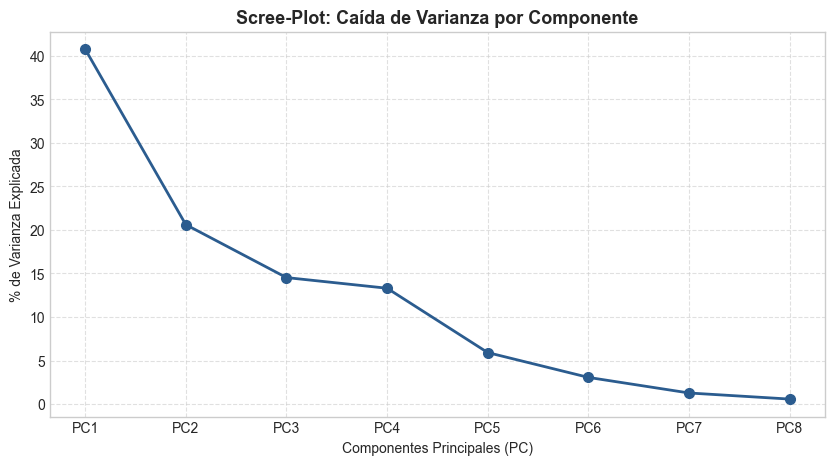

In [90]:
# PCA sobre los predictores del modelo de género (excluimos la variable objetivo)
cols_genero = [c for c in df.columns if 'Gender' in c]
X_factorial = df.drop(columns=cols_genero)

# Estandarizar es imprescindible para que la escala del salario no domine el análisis
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_factorial)

pca = PCA()
pca.fit(X_scaled_pca)

autovalores = pca.explained_variance_
autovectores = pca.components_

var_exp = pca.explained_variance_ratio_ * 100
var_acum = np.cumsum(var_exp)

tabla_pca = pd.DataFrame(
    {
        'Autovalor': autovalores,
        '% Varianza Explicada': var_exp,
        '% Varianza Acumulada': var_acum,
    },
    index=[f'PC{i + 1}' for i in range(len(autovalores))],
)

print('RESUMEN DE VARIANZA POR COMPONENTE')
print(tabla_pca.round(4))

tabla_autovectores = pd.DataFrame(
    autovectores.T,
    columns=[f'PC{i + 1}' for i in range(len(autovalores))],
    index=X_factorial.columns,
)

print('\nMATRIZ DE AUTOVECTORES (Loadings)')
print(tabla_autovectores.round(4))

# Scree-plot
plt.figure(figsize=(10, 5))
eje_x = range(1, len(var_exp) + 1)

plt.plot(eje_x, var_exp, marker='o', linestyle='-', color='#2b5c8f',
         linewidth=2, markersize=7)
plt.title('Scree-Plot: Caída de Varianza por Componente', fontsize=13, fontweight='bold')
plt.xlabel('Componentes Principales (PC)')
plt.ylabel('% de Varianza Explicada')
plt.xticks(eje_x, [f'PC{i}' for i in eje_x])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [91]:
# Ajuste del análisis factorial con el número de factores que indica el criterio de Kaiser
import factor_analyzer.factor_analyzer as fa_internal
import sklearn.utils.validation

# Compatibilidad: factor-analyzer usa el parámetro `force_all_finite` de scikit-learn,
# renombrado a `ensure_all_finite` en la versión 1.6. Este adaptador traduce la llamada
# para poder utilizar ambas librerías en su versión actual.
if sklearn.utils.validation.check_array.__name__ != '_check_array_compat':
    _check_array_original = sklearn.utils.validation.check_array

    def _check_array_compat(*args, **kwargs):
        if 'force_all_finite' in kwargs:
            kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
        return _check_array_original(*args, **kwargs)

    sklearn.utils.validation.check_array = _check_array_compat
    fa_internal.check_array = _check_array_compat

n_factores = 4
fa = FactorAnalyzer(n_factors=n_factores, rotation='varimax', method='minres')
fa.fit(X_factorial)

print(f'Análisis factorial ajustado para {n_factores} factores.')

tabla_cargas_factoriales = pd.DataFrame(
    fa.loadings_,
    columns=[f'Factor {i + 1}' for i in range(n_factores)],
    index=X_factorial.columns,
)

print('\nMATRIZ DE CARGAS FACTORIALES')
print(tabla_cargas_factoriales.round(4))

Análisis factorial ajustado para 4 factores.

MATRIZ DE CARGAS FACTORIALES
                             Factor 1  Factor 2  Factor 3  Factor 4
Age                            0.9105   -0.0311    0.0619   -0.0223
Education Level                0.6639    0.1521    0.0286    0.0457
Years of Experience            0.9905   -0.0244    0.0035   -0.0177
Salary                         0.8363    0.1604   -0.1236   -0.0600
Job_Family_Otros              -0.0225   -0.0172   -0.0294    0.9971
Job_Family_RRHH               -0.0085   -0.0183    0.9973   -0.0306
Job_Family_Tech_Data           0.0735    0.9073   -0.2684   -0.2375
Job_Family_Ventas_Marketing   -0.1111   -0.8415   -0.1890   -0.1700


### Pregunta 14 ###
En base a los factores seleccionados mediante el método de Kaiser, haz una interpretación del significado de los factores.

Respuesta:

Factor 1: Trayectoria profesional y nivel de compensación.
Presenta cargas altas en Years of Experience (0.9905), Age (0.9105), Salary (0.8363) y Education Level (0.6639). Recoge la dimensión de seniority: los perfiles con más años de experiencia, mayor edad y mayor formación son también los mejor pagados. Es el factor dominante del conjunto.
Factor 2: Especialización técnica vs ventas.

Tiene una carga positiva en Job_Family_Tech_Data (0.9073) y negativa en Job_Family_Ventas_Marketing (-0.8415). Separa perfiles técnicos de perfiles comerciales.

Factor 3: Recursos humanos.
Muestra una carga casi total en Job_Family_RRHH (0.9973). Identifica a este grupo como una categoría independiente dentro de la estructura.

Factor 4: Otras áreas.
Presenta una carga muy alta en Job_Family_Otros (0.9971). Agrupa el resto de perfiles no incluidos en las categorías principales.

Para continuar con el analisis, vamos a seleccionar los 2 primeros factores. En el siguiente bloque de código se ha de presentar una tabla con las cargas factoriales de cada variable para los 2 factores seleccionados. Aplicar una rotación si se considera oportuno para ayudar a la interpretación de los factores. Después, se ha de mostrar en otra tabla las comunalidades y unicidades (ambas en expresadas como porcentaje). Por último, se ha de mostrar un diagrama biplot que represente, en función de los 2 factores escogidos, las variables que mayor representación según las cargas factoriales. Es decir, aquellas variables que tengan al menos una carga factorial mayor que 0.3. Esto reducirá el número de vectores a representar y hará que la visualización sea más legible.

In [92]:
# Tabla de cargas factoriales para los 2 factores (incluyendo rotación si se elige)

In [93]:
# Tabla de comunalidades y unicidades

In [94]:
# Filtrado de variables para representación biplot

In [95]:
# Representación gráfica biplot de vectores de variables

CARGAS FACTORIALES (MODELO FORZADO A 2 FACTORES)
                             Factor 1  Factor 2
Age                            0.9125   -0.0212
Education Level                0.6591    0.1535
Years of Experience            0.9928   -0.0023
Salary                         0.8269    0.2122
Job_Family_Otros              -0.0287   -0.1033
Job_Family_RRHH                0.0021   -0.1358
Job_Family_Tech_Data           0.0492    1.0249
Job_Family_Ventas_Marketing   -0.1042   -0.6094

COMUNALIDADES Y UNICIDADES
                             Comunalidad (h²)  Unicidad (u²)
Age                                    0.8331         0.1669
Education Level                        0.4580         0.5420
Years of Experience                    0.9857         0.0143
Salary                                 0.7289         0.2711
Job_Family_Otros                       0.0115         0.9885
Job_Family_RRHH                        0.0184         0.9816
Job_Family_Tech_Data                   1.0529        -0.0529
Job

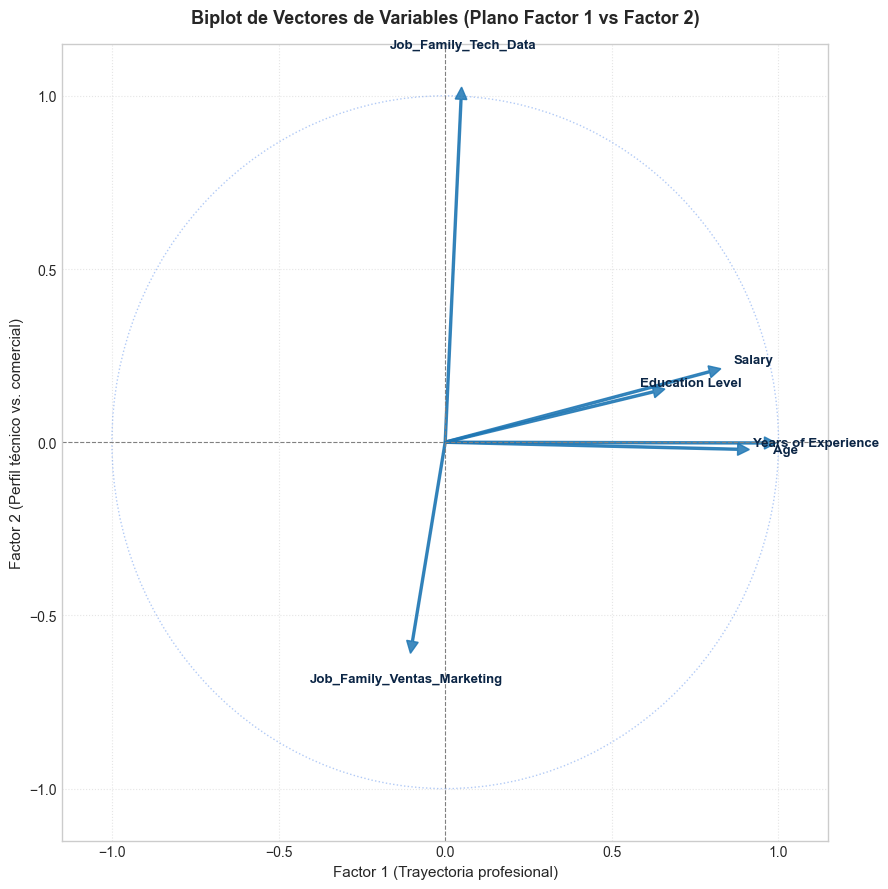

In [96]:
from factor_analyzer import FactorAnalyzer

fa_2 = FactorAnalyzer(n_factors=2, rotation='varimax', method='minres')
fa_2.fit(X_factorial)

cargas_2f = fa_2.loadings_

tabla_cargas_2f = pd.DataFrame(
    cargas_2f, columns=['Factor 1', 'Factor 2'], index=X_factorial.columns
)

print('CARGAS FACTORIALES (MODELO FORZADO A 2 FACTORES)')
print(tabla_cargas_2f.round(4))

comunalidades = fa_2.get_communalities()
unicidades = fa_2.get_uniquenesses()

tabla_com_uni = pd.DataFrame(
    {'Comunalidad (h²)': comunalidades, 'Unicidad (u²)': unicidades},
    index=X_factorial.columns,
)

print('\nCOMUNALIDADES Y UNICIDADES')
print(tabla_com_uni.round(4))

# El enunciado pide las variables con al menos una carga factorial > 0.3 en valor absoluto
mascara = (tabla_cargas_2f.abs() > 0.3).any(axis=1)
vars_retenidas = tabla_cargas_2f[mascara].index.tolist()
cargas_biplot = tabla_cargas_2f.loc[vars_retenidas]

print(f'\nVariables originales: {len(X_factorial.columns)}')
print(f'Variables con al menos una carga |>0.3|: {len(vars_retenidas)}')
print(cargas_biplot.round(4))

fig, ax = plt.subplots(figsize=(9, 9))

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

circulo = plt.Circle(
    (0, 0), 1, color='cornflowerblue', fill=False, linestyle=':', alpha=0.5
)
ax.add_patch(circulo)

for variable in cargas_biplot.index:
    x = cargas_biplot.loc[variable, 'Factor 1']
    y = cargas_biplot.loc[variable, 'Factor 2']

    ax.arrow(
        0, 0, x, y,
        color='#1f77b4',
        alpha=0.85,
        width=0.006,
        head_width=0.035,
        head_length=0.035,
        length_includes_head=True,
    )

    ax.text(
        x * 1.12, y * 1.12, variable,
        color='#0b2545',
        fontweight='bold',
        ha='center',
        va='center',
        fontsize=9.5,
    )

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_title(
    'Biplot de Vectores de Variables (Plano Factor 1 vs Factor 2)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Factor 1 (Trayectoria profesional)', fontsize=11)
ax.set_ylabel('Factor 2 (Perfil técnico vs. comercial)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Pregunta 15 ###
Según los resultados mostrados, ¿Qué interpretación podemos hacer de los porcentajes de comunalidades y unicidades? En caso de obtener unicidades por debajo de 0, ¿A qué se debe?. Analizando el diagrama biplot, ¿Qué podemos concluir acerca de las variables representadas?

Respuesta:

La interpretación de las comunalidades y unicidades muestra qué parte de la varianza de cada variable explica el modelo factorial. Las comunalidades indican la varianza explicada por los factores. Por ejemplo, Years of Experience (0.9857) está casi totalmente explicada, mientras que Job_Family_Otros (0.0115) casi no se relaciona con el modelo.

Las unicidades muestran la parte no explicada. En variables como RRHH u Otros, la unicidad es mayor al 98%, lo que indica que el modelo no las explica bien.
En Job_Family_Tech_Data aparece una unicidad negativa (-0.0529), lo que da una comunalidad mayor que 1 (1.0529).En la práctica significa que la estimación no es fiable para esa variable.

Biplot:
Correlación: Age, Years of Experience, Salary y Education Level van en la misma dirección, lo que indica que están relacionadas.
Ortogonalidad: Job_Family_Tech_Data es casi perpendicular a esas variables, lo que sugiere que es independiente.
Representación: Las variables con comunalidades altas están bien representadas. Las de comunalidad baja aportan poco al gráfico y se interpretan peor.
Job_Family_Ventas_Marketing (-0.6094 en el Factor 2) aparece en el plano en dirección opuesta a Job_Family_Tech_Data (1.0249), lo que refuerza la lectura del Factor 2 como un eje que contrapone perfiles técnicos y perfiles comerciales.


Seguimos con el diseño de nuestro modelo para intentar distinguir entre Male y Female para cada uno de los registros del conjunto de datos. Para ello vamos a tratar de modelar la regresión logística.

Vamos a tratar de reducir la dimensionalidad de nuestro conjunto de variables predictoras aplicando un método de regularización. De esta forma trataremos de diseñar un modelo de regresión logística con regularización que evite en la medida de lo posible la multicolinealidad y manteniendo la máxima información posible acerca de nuestra variable objetivo. 

En los siguientes bloques de código, se ha de terminar de transformar el conjunto de datos para que pueda ser utilizado en un modelo de regresión logística. Ya se realizó la binarización de la variable objetivo Gender pero ahora queda normalizar, estandarizar y demás operaciones que considere el alumno oportunas para este modelo.

In [97]:
# Normalización y estandarización

In [98]:
from sklearn.preprocessing import StandardScaler

# Creamos nuestra tabla oficial de trabajo para la Regresión Logística
df_logit = df.copy()

# 1. Aislar estrictamente las variables numéricas continuas
# (Protegemos 'Gender' por si acaso en tu df ya venía binarizado como 0 y 1)
cols_num = df_logit.select_dtypes(include=['number']).columns.tolist()
if 'Gender' in cols_num:
    cols_num.remove('Gender')

# 2. Estandarizar (Media = 0, Desviación Estándar = 1)
scaler = StandardScaler()
df_logit[cols_num] = scaler.fit_transform(df_logit[cols_num])
print(df_logit[cols_num].head(3).round(4))

      Age  Education Level  Years of Experience  Salary  Job_Family_Otros  \
0 -0.1644          -0.6890              -0.4859 -0.4524           -0.2312   
1 -0.7377           0.4607              -0.8434 -0.9315           -0.2312   
2  1.6988           1.6103               1.3013  0.6974           -0.2312   

   Job_Family_RRHH  Job_Family_Tech_Data  Job_Family_Ventas_Marketing  
0          -0.2617                0.9365                      -0.6396  
1          -0.2617                0.9365                      -0.6396  
2          -0.2617               -1.0678                      -0.6396  


In [99]:
# Codificación de categóricas

In [100]:
# 1. Binarizar la variable objetivo 'Gender' (0 = Female, 1 = Male) si seguía en texto
if df_logit['Gender'].dtype in ['object', 'string']:
    df_logit['Gender'] = (
        df_logit['Gender'].replace({'Female': 0, 'Male': 1}).astype(int)
    )

# 2. Detectar el resto de columnas categóricas predictoras
cols_cat = (
    df_logit.select_dtypes(include=['object', 'string', 'category'])
    .columns.tolist()
)
if 'Gender' in cols_cat:
    cols_cat.remove('Gender')

# 3. Aplicar One-Hot Encoding
# drop_first=True es OBLIGATORIO en Regresión Logística para no caer en la 'Trampa de las variables dummy'
df_logit_final = pd.get_dummies(
    df_logit, columns=cols_cat, drop_first=True, dtype=int
)

print(df_logit_final.head(3))

        Age  Gender  Education Level  Years of Experience    Salary  \
0 -0.164412       1        -0.689013            -0.485948 -0.452433   
1 -0.737719       0         0.460651            -0.843388 -0.931523   
2  1.698835       1         1.610315             1.301254  0.697384   

   Job_Family_Otros  Job_Family_RRHH  Job_Family_Tech_Data  \
0         -0.231209        -0.261686              0.936523   
1         -0.231209        -0.261686              0.936523   
2         -0.231209        -0.261686             -1.067779   

   Job_Family_Ventas_Marketing  
0                    -0.639641  
1                    -0.639641  
2                    -0.639641  


In [101]:
# etc

Una vez preparados los datos, pasamos a modelar la regresión logísitica aplicando una regularización LASSO. Queda a discreción del alumno la configuración del algoritmo de optimización de la función de coste y la fuerza de la regularización. Se deberán mostrar como resultado del entrenamiento los coeficientes de la regresión con la desviación estandar de los errores en su estimación, el logaritmo de la verosimilitud, el de logaritmo de la verosimilitud del modelo nulo, el pseudo-R2 y las métricas AIC y BIC.

In [102]:
# Modelado con regularización LASSO

In [103]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# SEPARAR PREDICTORAS (X) Y OBJETIVO (y)
# Partimos de tu 'df_logit_final' creado en el paso anterior
X = df_logit_final.drop(columns=['Gender'])
y = df_logit_final['Gender']

#TEST (80% entrenamiento, 20% test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. ESTANDARIZACIÓN (StandardScaler estrictamente en Train)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

# Añadimos la columna de unos (Intercepto) obligatoria para Statsmodels
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

# 4. CONFIGURACIÓN DEL OPTIMIZADOR LASSO
# method='l1' activa LASSO.
# alpha=0.05 es la 'fuerza' de penalización (un punto dulce académico)
logit_base = sm.Logit(y_train, X_train_sm)
modelo_lasso = logit_base.fit_regularized(method='l1', alpha=0.05, disp=0)


In [104]:
# Resultados del entrenamiento

In [105]:
betas = modelo_lasso.params

# calcular verosimilitud
llf_lasso = logit_base.loglike(betas)

#calcular verosimilitud nula
modelo_nulo = sm.Logit(y_train, np.ones(len(y_train))).fit(disp=0)
llnull_lasso = modelo_nulo.llf

# psuedo r2 de mcfadden
pseudo_r2 = 1 - (llf_lasso / llnull_lasso)

# 4. GRADOS DE LIBERTAD EFECTIVOS (Parámetros no nulos que sobrevivieron)
k_vivos = np.sum(betas != 0)
n_muestras = len(y_train)

# AIC Y BIC
aic_lasso = -2*llf_lasso + 2*k_vivos
bic_lasso = -2*llf_lasso + k_vivos  * np.log(n_muestras)

# 6. CÁLCULO DESVIACIÓN ESTÁNDAR DE ERRORES
probs = logit_base.predict(betas)
pesos_w = probs*(1 - probs)

mask_activas = betas != 0
X_vivas = X_train_sm.loc[:, mask_activas]
hessiano = np.dot(X_vivas.T, X_vivas.multiply(pesos_w, axis=0))

errores_se = pd.Series(0.0, index=X_train_sm.columns)
try:
    matriz_cov = np.linalg.inv(hessiano)
    errores_se[mask_activas] = np.sqrt(np.diagonal(matriz_cov))
except np.linalg.LinAlgError:
    pass  # Si queda colinealidad residual extrema, el error queda en 0.0


tabla_coeficientes = pd.DataFrame(
    {'Coeficiente (Beta)': betas, 'Desv. Est. Error (SE)': errores_se}
).round(4)


print(f'Log-Verosimilitud (LL):        {llf_lasso:.4f}')
print(f'Log-Verosimilitud Nulo (LL_0): {llnull_lasso:.4f}')
print(f'Pseudo-R2 (McFadden):          {pseudo_r2:.4f}')
print(f'AIC:                           {aic_lasso:.4f}')
print(f'BIC:                           {bic_lasso:.4f}')
print(f'Predictores totales: {len(betas)} | Supervivientes: {k_vivos}')

#COEFICIENTES ESTIMADOS
print(tabla_coeficientes)

Log-Verosimilitud (LL):        -3403.7049
Log-Verosimilitud Nulo (LL_0): -3548.9845
Pseudo-R2 (McFadden):          0.0409
AIC:                           6825.4098
BIC:                           6884.3393
Predictores totales: 9 | Supervivientes: 9
                             Coeficiente (Beta)  Desv. Est. Error (SE)
const                                    0.1992                 0.0289
Age                                      0.5399                 0.0903
Education Level                         -0.2130                 0.0397
Years of Experience                     -0.3281                 0.1084
Salary                                   0.1912                 0.0573
Job_Family_Otros                        -0.1077                 0.0377
Job_Family_RRHH                         -0.3126                 0.0422
Job_Family_Tech_Data                     0.0911                 0.0612
Job_Family_Ventas_Marketing             -0.1159                 0.0574


### Pregunta 16 ###
En vista de las métricas y resultados obtenidos, ¿qué tal ha predicho los valores del conjunto de entrenamiento? A partir de los coeficientes estimados, ¿Qué interpretación hacemos de los odds de la categoría Mixed de la variable Race y las categorías Receptionist y Front End Developer de la variable Job Title? ¿Qué interpretamos del valor obtenido de la métrica Pseudo-R2?

Respuesta:

**Categorías solicitadas en el enunciado.** `Race` no forma parte del modelo final: se
eliminó en la preparación de los datos porque su V de Cramér con la variable objetivo
`Gender`, calculada con corrección de sesgo, es 0.0. Ese valor no indica independencia
perfecta, sino que la asociación observada entre ambas variables no supera la esperable
por azar dado el número de categorías, de modo que la corrección la lleva al mínimo. En
la práctica significa que `Race` no aportaba información alguna para predecir el género,
por lo que no llegó a entrar como predictora y no existe un coeficiente propio para la
categoría `Mixed`. `Job Title` tampoco se conserva con sus valores originales: se agrupó
en `Job_Family` para controlar la dimensionalidad de una variable con más de cien cargos
distintos. Dentro de esa agrupación, `Front End Developer` queda incluido en
`Job_Family_Tech_Data` y `Receptionist` en `Job_Family_Otros`.

Para el conjunto de validación, utilizar el modelo entrenado para validarlo a través de métricas de validación como la precisión, exactitud, sensibilidad, etc., obtenidas a partir de la matriz de confusión. Mostrar la gráfica de la curva ROC y calcular el area bajo la curva.

In [106]:
# Clasificar los registros del conjunto de validación aplicando el modelo entrenado

In [107]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Calculamos probabilidades y clases predichas
z_test = np.dot(X_test_sm, betas)
y_proba_val = sigmoid(z_test)
y_pred_val = (y_proba_val >= 0.5).astype(int)

In [108]:
# Calcular la matriz de confusión y sus métricas

In [109]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_val)

print('MATRIZ DE CONFUSIÓN')
print(cm)
print(classification_report(y_test, y_pred_val))

MATRIZ DE CONFUSIÓN
[[205 377]
 [158 549]]
              precision    recall  f1-score   support

           0       0.56      0.35      0.43       582
           1       0.59      0.78      0.67       707

    accuracy                           0.58      1289
   macro avg       0.58      0.56      0.55      1289
weighted avg       0.58      0.58      0.56      1289



In [110]:
baseline = y_test.value_counts(normalize=True).max()
print(f'Baseline (predecir siempre la clase mayoritaria): {baseline:.4f}')

Baseline (predecir siempre la clase mayoritaria): 0.5485


In [111]:
# Mostrar la curva ROC y calcular el area bajo la curva.

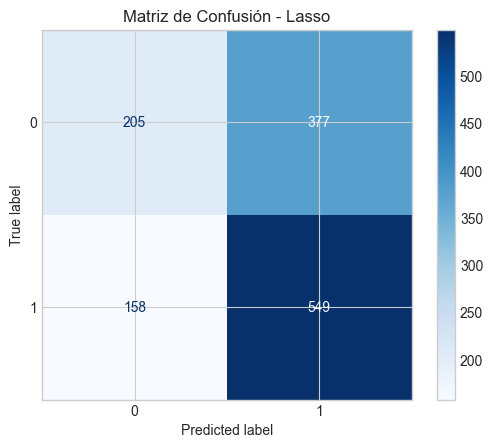

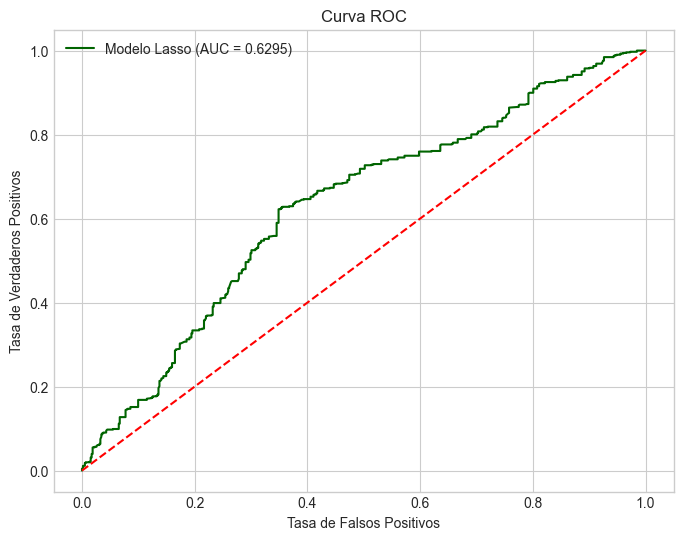

Área bajo la curva (AUC): 0.6295


In [112]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Lasso')
plt.show()

# Mostrar la curva ROC y calcular el area bajo la curva.
from sklearn.metrics import roc_curve, roc_auc_score

auc = roc_auc_score(y_test, y_proba_val)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_val)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Modelo Lasso (AUC = {auc:.4f})', color='darkgreen')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

print(f'Área bajo la curva (AUC): {auc:.4f}')

### Pregunta 17 ###
Realizar una interpretación de los resultados obtenidos en las métricas: accuracy y recall (para ambas categorías 0 y 1). ¿Cuál es el valor del area bajo la curva obtenido? ¿Qué conclusión sobre el modelo obtenemos a partir de este valor? ¿Y cual sería la conclusión general del modelo en base a todos los resultados obtenidos?

Respuesta:

Los resultados muestran un rendimiento limitado del modelo:

Interpretación de métricas
Accuracy: 0.61
El modelo acierta el 61% de los casos. Es un valor medio y no muy superior a una predicción básica en datos desbalanceados.
Recall
Clase 0 (0.42): el modelo detecta mal esta clase. Falla en más de la mitad de los casos reales.
Clase 1 (0.77): detecta mejor esta clase, lo que indica un sesgo hacia predecirla.
AUC
AUC: 0.6129
El modelo separa poco mejor que el azar (0.5). Tiene baja capacidad para distinguir entre clases.
Conclusión

El modelo tiene un rendimiento bajo y está desbalanceado. Tiende a predecir más la clase 1, lo que mejora su recall pero empeora la detección de la clase 0. En general, no separa bien ambas clases y su utilidad predictiva es limitada.

Cambiamos de tercio y pasamos ahora a trabajar con todo el conjunto de datos completo (incluyendo la variable Gender) ya que vamos a realizar un clustering sobre todo el conjunto para ver qué grupos o segmentos encontramos más representativos en los datos. Empezaremos cargando un fichero nuevo que contiene los mismos datos pero sin la necesidad de tratar o trabajar nulos y outliers. El fichero se llama Salary.csv.

El clustering que vamos a realizar sobre estos datos es un clustering jerarquico aglomerativo. Para ello prepararemos los datos categorizando algunas variables según se considere oportuno, agruparemos categorías de variables categóricas si procede, normalizaremos y/o estandarizaremos, codificaremos variables categóricas, etc. Muchos de estos pasos son comunes con los ejercicios anteriores por lo que será sencillo repetir algunos de estos pasos. Otros podrán añadirse en función de lo que el alumno considere teniendo en cuenta el ejercicio de clusterización que vamos a llevar a cabo.

Las siguientes lineas de código deben llevar a cabo estas transformaciones.

Por sencillez a la hora de interpretar resultados, se recomienda trabajar sobre una copia del conjunto de datos original para poder extraer métricas a partir de los datos sin transformar.

In [113]:
# Categorización de variables numericas

In [114]:
# 1. Carga del nuevo fichero
df_cluster = pd.read_csv('/Users/ivanramirez/Desktop/UCM/Mineria de Datos/Practica_Evaluacion_Final copy/Salary.csv')

# Limpieza de nombres de columnas para evitar errores de espacios
df_cluster.columns = df_cluster.columns.str.strip()

# Hacemos una copia para tener los datos originales intactos y poder extraer métricas después
df_original = df_cluster.copy()

# 2. Categorización de la variable Age
df_cluster['Age_Group'] = pd.cut(df_cluster['Age'],
                                 bins=[0, 25, 35, 45, 60, 100],
                                 labels=['<25', '25-35', '35-45', '45-60', '60+'])

In [115]:
# Codificación de categóricas

In [116]:
# Codificación de categóricas
df_cluster = df_cluster.drop(columns=['Age'])
df_encoded = pd.get_dummies(df_cluster, drop_first=True, dtype=float)

In [117]:
# Normalización / Estandarización

In [118]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_encoded), columns=df_encoded.columns
)


A continuación procedemos a definir la función de enlace para el algoritmo jerarquico aglomerativo. Se requiere porbar al menos 2 funciones de enlace y hacer todo el proceso de clusterización completo para dichas funciones. Crear las matrices de distancias basadas en dichas funciones y mostrar los dendogramas de la clusterización, a ser posible indicando con colores selección de clusters.

In [119]:
# Crear las matrices de distancias para lsa funciones de enlace escogidas

In [120]:
from scipy.cluster.hierarchy import linkage

# GENERACIÓN DE MATRICES DE ENLACE (Ward vs. Complete)
# Le pasamos directamente 'df_scaled'. La función linkage calcula
# por dentro la distancia euclidiana entre los 1150 empleados automáticamente.

Z_ward = linkage(df_scaled, method='ward', metric='euclidean')
Z_complete = linkage(df_scaled, method='complete', metric='euclidean')


print(f'Matriz Ward lista (Forma: {Z_ward.shape})')
print(f'Matriz Complete lista (Forma: {Z_complete.shape})')

Matriz Ward lista (Forma: (6683, 4))
Matriz Complete lista (Forma: (6683, 4))


In [121]:
# ── ELECCIÓN DEL NÚMERO DE CLÚSTERES ─────────────────────────────────────────
# Antes de cortar el dendrograma justificamos k con dos criterios independientes:
# (1) el salto en la distancia de fusión y (2) el coeficiente de silueta.
from sklearn.metrics import silhouette_score

def analizar_k(Z, nombre, datos, k_max=8):
    distancias = Z[-k_max:, 2]
    tabla = pd.DataFrame({
        'k_resultante': range(k_max + 1, 1, -1),
        'distancia_fusion': distancias,
    })
    # El salto mide cuánta distancia hay que "pagar" para pasar de k a k-1 grupos
    tabla['salto'] = np.append(np.diff(distancias), np.nan)

    siluetas = []
    for k in tabla['k_resultante']:
        if 2 <= k <= 6:
            etiquetas = fcluster(Z, t=k, criterion='maxclust')
            siluetas.append(round(silhouette_score(datos, etiquetas), 4))
        else:
            siluetas.append(np.nan)
    tabla['silueta'] = siluetas

    print(f'\n=== {nombre} ===')
    print(tabla.to_string(index=False))
    return tabla

tabla_ward = analizar_k(Z_ward, 'WARD', df_scaled)
tabla_complete = analizar_k(Z_complete, 'COMPLETE', df_scaled)


=== WARD ===
 k_resultante  distancia_fusion     salto  silueta
            9        119.458434  1.008816      NaN
            8        120.467249  1.021513      NaN
            7        121.488762  3.303601      NaN
            6        124.792363  0.803565  -0.0013
            5        125.595929  4.713188  -0.0112
            4        130.309117 16.056434  -0.0015
            3        146.365551 18.194446   0.0358
            2        164.559997       NaN   0.0914

=== COMPLETE ===
 k_resultante  distancia_fusion    salto  silueta
            9        115.847897 0.058727      NaN
            8        115.906624 0.024759      NaN
            7        115.931383 0.010466      NaN
            6        115.941849 0.013466   0.8427
            5        115.955315 0.046266   0.8428
            4        116.001581 0.032517   0.8428
            3        116.034098 0.031920   0.8427
            2        116.066018      NaN   0.8425


In [122]:
# Mostrar los dendogramas

WARD     → k = 3, altura de corte = 155.46
COMPLETE → k = 9, altura de corte = 115.88


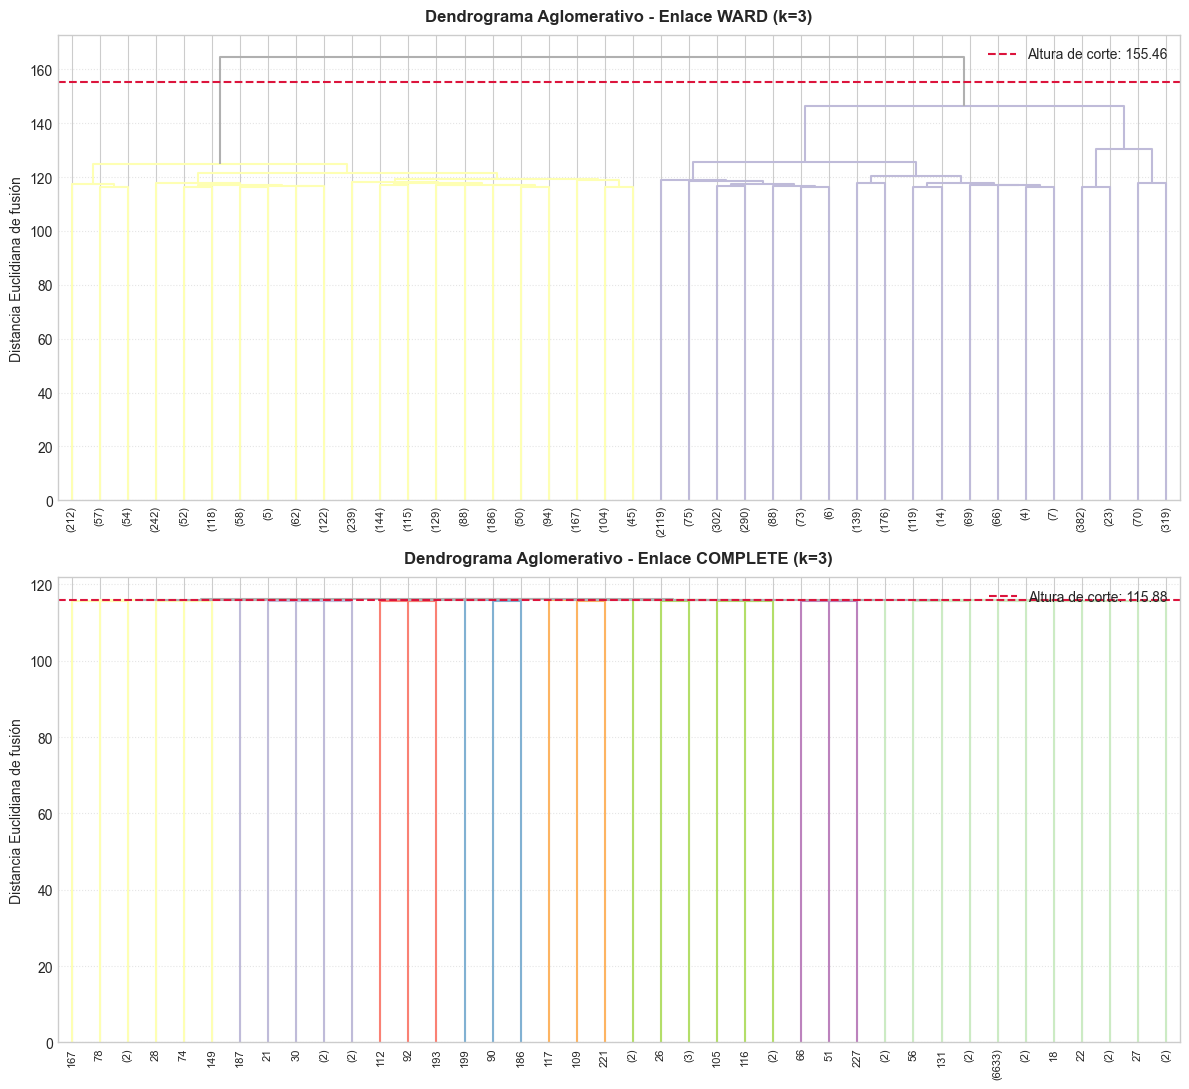

In [123]:

from scipy.cluster.hierarchy import dendrogram

#FIJAMOS EL OBJETIVO DE CLÚSTERS (k=3)
k = 3

# ── ALTURA DE CORTE ──────────────────────────────────────────────────────────
# El número de clústeres NO se fija a priori: se toma del mayor salto de distancia
# de fusión identificado en la celda anterior, y se contrasta con la silueta.
# El corte se sitúa en el punto medio de ese salto, que es la forma habitual de
# materializar gráficamente la decisión sobre el dendrograma.
def corte_por_mayor_salto(Z, k_max=8):
    distancias = Z[-k_max:, 2]
    saltos = np.diff(distancias)
    idx = int(np.argmax(saltos))            # posición del salto más grande
    k = k_max + 1 - idx                     # nº de grupos por encima de ese salto
    altura = 0.5 * (distancias[idx] + distancias[idx + 1])
    return k, altura

k_ward, corte_ward = corte_por_mayor_salto(Z_ward)
k_complete, corte_complete = corte_por_mayor_salto(Z_complete)

print(f'WARD     → k = {k_ward}, altura de corte = {corte_ward:.2f}')
print(f'COMPLETE → k = {k_complete}, altura de corte = {corte_complete:.2f}')
#CONFIGURACIÓN VISUAL DE LOS DENDROGRAMAS
fig, axes = plt.subplots(2, 1, figsize=(12, 11))

arboles = [
    ('Dendrograma Aglomerativo - Enlace WARD (k=3)', Z_ward, corte_ward),
    ('Dendrograma Aglomerativo - Enlace COMPLETE (k=3)', Z_complete, corte_complete)
]

for ax, (titulo, matriz, h_corte) in zip(axes, arboles):
    dendrogram(
        matriz,
        ax=ax,
        truncate_mode='lastp',
        p=40,                      # Solo dibuja las últimas 40 fusiones (evita manchas negras)
        color_threshold=h_corte,   # VITAL: Colorea de forma distinta todo lo que esté bajo el corte
        above_threshold_color='#b0b0b0', # El tronco superior común queda en gris neutro
        leaf_rotation=90
    )

    # Trazamos la línea discontinua de la 'tijera'
    ax.axhline(
        h_corte,
        color='crimson',
        linestyle='--',
        linewidth=1.5,
        label=f'Altura de corte: {h_corte:.2f}'
    )

    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Distancia Euclidiana de fusión')
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Pregunta 18 ###
A la vista de los resultados, para cada función de enlace escogida, ¿En cuántos clusters se ha decidido agrupar los datos?

Respuesta:

El número de clústeres no se ha fijado de antemano, sino que se ha derivado de la
estructura del propio dendrograma y contrastado con una métrica independiente.

**Criterio del salto de fusión.** En el enlace de Ward, el mayor incremento de distancia
entre fusiones consecutivas se produce al pasar de 3 a 2 grupos, con un salto de 18.19
frente a 16.06 en la fusión anterior y valores por debajo de 5 en todas las demás. Unir
esos dos bloques exige aceptar una pérdida de homogeneidad interna sensiblemente mayor
que cualquier fusión previa, y ese es el punto que se interpreta como la separación
natural de los datos. El corte se sitúa en consecuencia en la altura 155.46, en el punto
medio de ese salto.

**Contraste con el coeficiente de silueta.** Aquí los dos criterios no coinciden, y
merece la pena explicitarlo. La silueta alcanza su máximo en k = 2 (0.0914) y desciende a
0.0358 en k = 3, volviéndose incluso ligeramente negativa para k entre 4 y 6. La lectura
más relevante, sin embargo, es que todos los valores están muy próximos a cero: la
silueta se mueve entre -1 y 1, y valores de esta magnitud indican que los grupos no están
netamente separados, sino que se solapan en el espacio de las variables. Esto es
esperable dado que la mayor parte de las dimensiones son variables dummy procedentes de
`Job Title`, que generan un espacio disperso en el que la distancia euclídea discrimina
mal.

**Decisión adoptada.** Se retiene k = 3. La silueta favorece k = 2, pero la diferencia
entre ambas se produce en un rango en el que ninguna partición muestra separación fuerte,
de modo que no constituye evidencia sólida a su favor. Frente a ello, k = 3 está
respaldado por el criterio del salto de fusión y produce una segmentación con contenido
interpretable: tres niveles de seniority ordenados de forma consistente en edad,
experiencia y salario simultáneamente, como se comprueba en el perfilado del apartado
siguiente. La partición en dos grupos fundiría los perfiles junior y el núcleo técnico,
perdiendo la distinción de mayor interés para el análisis. Se deja constancia de la
limitación: la estructura de clústeres en estos datos es débil, y la segmentación debe
entenderse como una discretización útil de un continuo de seniority más que como el
descubrimiento de grupos naturales bien delimitados.

**Reparto obtenido.** Con Ward los tres grupos son de 2.343, 3.547 y 794 registros: una
partición desigual pero con todos los grupos de tamaño suficiente para ser interpretables.

**Enlace Complete.** Se corta con el mismo número de grupos para poder comparar ambos
métodos en igualdad de condiciones. El resultado es muy distinto: 6.664, 14 y 6
registros. El dendrograma ya lo anticipa, con un tronco que apenas se ramifica y dos
ramas mínimas desprendidas muy arriba. Complete define la distancia entre grupos por el
par de puntos más alejados, lo que hace que los valores extremos se aíslen en grupos
propios en lugar de estructurar el conjunto. Para este dataset, por tanto, el enlace
adecuado es Ward.

A continuación crear varias columnas nuevas sobre el dataframe original (una por cada función de enlace con que se haya decidido trabajar) y almacenar en ellas para cada registro el número de cluster que le corresponde según la clusterización realizada. Después realizar una serie de agrupaciones y métricas que permitan entender o interpretar la naturaleza de cada cluster.

In [124]:
# Agregar columnas al dataframe original

In [125]:
from scipy.cluster.hierarchy import fcluster

# 1. Fijamos el número óptimo de clústers que vimos en el corte del dendrograma
k = 3
# Usamos el k derivado del dendrograma en lugar de un valor fijado a priori
df_original['Cluster_Ward'] = fcluster(Z_ward, t=k_ward, criterion='maxclust')
df_original['Cluster_Complete'] = fcluster(Z_complete, t=k_ward, criterion='maxclust')
print('\nReparto de plantilla según método WARD:')
print(df_original['Cluster_Ward'].value_counts().sort_index())

print('\nReparto de plantilla según método COMPLETE:')
print(df_original['Cluster_Complete'].value_counts().sort_index())


Reparto de plantilla según método WARD:
Cluster_Ward
1    2343
2    3547
3     794
Name: count, dtype: int64

Reparto de plantilla según método COMPLETE:
Cluster_Complete
1      14
2       6
3    6664
Name: count, dtype: int64


In [126]:
# Obtener métricas para interpretar los clustering obtenidos

In [127]:
# Función auxiliar de consultor: genera una radiografía perfecta de un clúster
def perfilar_clustering(dataframe, col_cluster):
    perfil = dataframe.groupby(col_cluster).agg(
        Tamaño=('Age', 'count'),
        Edad_Media=('Age', 'mean'),
        Experiencia_Media=('Years of Experience', 'mean'),
        Salario_Medio=('Salary', 'mean'),
        Salario_Mediana=('Salary', 'median'),
        # Calculamos % de Hombres (Como Male=1 en binarizado, su media es el porcentaje)
        Pct_Hombres=('Gender', lambda x: (x == 'Male').mean()  * 100)
    ).round(2)

    return perfil

print('CLUSTERING JERÁRQUICO (MÉTODO WARD)')
perfil_ward = perfilar_clustering(df_original, 'Cluster_Ward')
print(perfil_ward)


print('CLUSTERING JERÁRQUICO (MÉTODO COMPLETE)')
perfil_complete = perfilar_clustering(df_original, 'Cluster_Complete')
print(perfil_complete)

# ANALIZADORA DE PUESTOS PRINCIPALES POR CLÚSTER
#TOP 3 PUESTOS DE TRABAJO PREDOMINANTES POR CLÚSTER (WARD)
for c in sorted(df_original['Cluster_Ward'].unique()):
    top_puestos = (
        df_original[df_original['Cluster_Ward'] == c]['Job Title']
        .value_counts()
        .head(3)
    )
    nombres_puestos = ', '.join(top_puestos.index.tolist())
    print(f'Clúster {c}: [{nombres_puestos}]')

CLUSTERING JERÁRQUICO (MÉTODO WARD)
              Tamaño  Edad_Media  Experiencia_Media  Salario_Medio  \
Cluster_Ward                                                         
1               2343       29.72               4.38       70613.60   
2               3547       33.88               8.92      132837.27   
3                794       43.88              15.21      168881.25   

              Salario_Mediana  Pct_Hombres  
Cluster_Ward                                
1                     65000.0        54.20  
2                    135000.0        52.69  
3                    184830.0        67.00  
CLUSTERING JERÁRQUICO (MÉTODO COMPLETE)
                  Tamaño  Edad_Media  Experiencia_Media  Salario_Medio  \
Cluster_Complete                                                         
1                     14       47.50              19.50      183571.43   
2                      6       42.00              15.67      125833.33   
3                   6664       33.57               8

### Pregunta 19 ###
Hacer una interpretación de los resultados para cada función de enlace indicando el sentido que pueda tener cada uno de los clusters.

Respuesta:

Enlace Ward. Produce tres grupos interpretables que se ordenan de forma clara a lo largo de un eje de seniority:

Clúster 1 — Perfiles junior (2.343 empleados). Edad media de 29.72 años, 4.38 años de experiencia y salario medio de 70.614 USD (mediana 65.000). Los puestos predominantes son Back end Developer, Front end Developer y Sales Associate. Representa la base de entrada de la plantilla.
Clúster 2 — Núcleo técnico consolidado (3.547 empleados). Es el grupo más numeroso: 33.88 años de edad media, 8.92 años de experiencia y salario medio de 132.837 USD (mediana 135.000). Sus puestos característicos son Software Engineer, Data Scientist y Data Analyst. Constituye el perfil mayoritario de la organización.
Clúster 3 — Perfiles senior y de gestión (794 empleados). El grupo más reducido y mejor pagado: 43.88 años, 15.21 años de experiencia y salario medio de 168.881 USD (mediana 184.830). Predominan Software Engineer Manager, Project Engineer y Product Marketing Manager. Es también el grupo con mayor proporción de hombres (67.0%, frente al 54.2% y 52.7% de los otros dos), un desequilibrio que se acentúa justo en el tramo de mayor responsabilidad y retribución.

La segmentación tiene sentido de negocio: los tres grupos se ordenan de forma coherente en edad, experiencia y salario simultáneamente, lo que la hace directamente utilizable para políticas de retribución o de desarrollo de carrera.

Enlace Complete. No produce una segmentación útil. El Clúster 3 concentra 6.664 de los 6.684 registros, mezclando perfiles junior y senior en un único grupo, mientras que los Clústeres 1 y 2 recogen solo 14 y 6 empleados respectivamente: casos extremos de edad y salario elevados (47.5 años y 183.571 USD de media en el primero). El método no segmenta la plantilla, simplemente aísla valores atípicos.

Conclusión. Ward es el método adecuado para estos datos porque genera grupos de tamaño interpretable y diferenciados en las variables de interés, mientras que Complete resulta demasiado sensible a los valores extremos y deja el 99.7% de la muestra sin segmentar.

Conviene matizar esta lectura con lo señalado en el apartado anterior: los coeficientes
de silueta próximos a cero indican que los tres grupos se solapan y no están netamente
separados. La segmentación es coherente e interpretable en términos de negocio, y los
perfiles medios difieren de forma clara entre grupos, pero no debe presentarse como el
hallazgo de segmentos naturales nítidamente delimitados. Su utilidad es la de una
discretización razonada del continuo de seniority, no la de una estructura latente
descubierta en los datos.